# Credit Card Default Risk: PD Model, Expected Loss

## Introduction

Credit risk management is a fundamental component of financial risk management, as financial institutions need to accurately assess the likelihood of borrower default and estimate potential losses arising from credit exposures.

The objective of this project is to develop an end-to-end credit risk modeling workflow that estimates borrower-level Probability of Default (PD) using machine learning techniques. The predicted PD is then calibrated and incorporated with Loss Given Default (LGD) and Exposure at Default (EAD) assumptions to estimate Expected Loss (EL):

$$
\text{Expected Loss} = PD \times LGD \times EAD
$$

The project covers key stages of a credit risk modeling process, including exploratory data analysis, feature engineering, model comparison, probability calibration, threshold analysis risk segmentation.
The workflow is designed as an educational implementation inspired by banking risk management practices, particularly Basel-style credit risk frameworks and portfolio monitoring processes. The objective is n andot only to maximize predictive performance but also to generate reliable risk estimates that can support credit decision-making and loss assessment.

## Data

The dataset contains information on 30,000 credit card customers in Taiwan, covering demographic characteristics, approved credit limits, repayment status, monthly bill statements, and payment amounts from April to September 2005.

The target variable indicates whether a customer defaults in the following month:

- `1`: default
- `0`: no default

The predictor variables can be grouped into five categories:

1. **Customer identifier**
   - `ID`: unique customer identifier

2. **Credit capacity**
   - `LIMIT_BAL`: approved credit limit in New Taiwan Dollars (NTD)

3. **Demographic characteristics**
   - `SEX`: gender category
   - `EDUCATION`: education category
   - `MARRIAGE`: marital-status category
   - `AGE`: customer age in years

4. **Repayment status**
   - `PAY_0` to `PAY_6`: monthly repayment status from September to April 2005
   - Larger positive values indicate longer payment delays, while negative or zero values represent timely payment or other non-delinquent account states

5. **Credit utilization and payment behavior**
   - `BILL_AMT1` to `BILL_AMT6`: monthly bill statement amounts
   - `PAY_AMT1` to `PAY_AMT6`: monthly payment amounts

All monetary variables are measured in New Taiwan Dollars.

Sources: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

## Project Workflow

1. Data understanding  
2. Exploratory data analysis  
3. Data Processing and Logistic Regression Baseline 
4. Model Comparison 
5. Threshold Anaysis 
6. Expected Loss and Risk Segmentation  


## 1. Data Understanding

This section checks the structure, variables, missing values, and target distribution of the dataset.


In [2]:
# =========================
# 1.1 Import Libraries
# =========================

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import matplotlib.ticker as ticker

from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    log_loss
)

# VIF / multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from sklearn.frozen import FrozenEstimator
    frozen_estimator_available = True
except Exception:
    frozen_estimator_available = False
    
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
# =========================
# 1.2 Set Project Paths
# =========================

import os

# Local project setup (no Google Colab dependency)
# Place this notebook and the "Data" folder under the same PROJECT_PATH,
# or simply edit PROJECT_PATH below to point to your project folder.

PROJECT_PATH = "/Users/due/Library/CloudStorage/OneDrive-NationalEconomicsUniversity/Career Project/Credit Risk"

DATA_PATH = os.path.join(PROJECT_PATH, "Data", "default_credit_card_clients.xls")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "Output")
REPORTS_PATH = os.path.join(PROJECT_PATH, "Reports")
DASHBOARD_PATH = os.path.join(PROJECT_PATH, "Dashboard")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "Notebooks")

for path in [OUTPUT_PATH, REPORTS_PATH, DASHBOARD_PATH]:
    os.makedirs(path, exist_ok=True)

print("File exists:", os.path.exists(DATA_PATH))
print(DATA_PATH)


File exists: True
/Users/due/Library/CloudStorage/OneDrive-NationalEconomicsUniversity/Career Project/Credit Risk/Data/default_credit_card_clients.xls


In [4]:
# =========================
# 1.3 Load Dataset
# =========================

df_raw = pd.read_excel(DATA_PATH, header=1)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# =========================
# 1.4 Create Working Data
# =========================

df = df_raw.copy()

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

### Key Variables

| Variable Group | Columns | Description |
|---|---|---|
| Customer ID | `ID` | Unique customer identifier, excluded from modeling |
| Credit Limit | `LIMIT_BAL` | Approved credit limit, used as a credit exposure reference and sensitivity proxy |
| Demographics | `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Customer demographic information |
| Repayment Status | `PAY_0`, `PAY_2`, ..., `PAY_6` | Historical repayment status over recent months |
| Bill Amount | `BILL_AMT1`, ..., `BILL_AMT6` | Monthly bill statement amounts. `BILL_AMT1` is used as the main proxy for EAD in Expected Loss calculation |
| Payment Amount | `PAY_AMT1`, ..., `PAY_AMT6` | Monthly payment amounts |
| Target | `default` | Default payment indicator for the next month |

In [7]:
# Missing values summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_rate": df.isnull().mean()
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_rate
ID,0,0.0000
BILL_AMT2,0,0.0000
PAY_AMT6,0,0.0000
PAY_AMT5,0,0.0000
PAY_AMT4,0,0.0000
PAY_AMT3,0,0.0000
PAY_AMT2,0,0.0000
PAY_AMT1,0,0.0000
BILL_AMT6,0,0.0000
BILL_AMT5,0,0.0000


In [8]:
# =========================
# 1.6 Rename Target Variable
# =========================

df = df.rename(columns={
    "default payment next month": "default"
})

target_col = "default"

df[[target_col]].head()

,default
0,1
1,1
2,0
3,0
4,0


## 2. Exploratory Data Analysis

This section explores the relationship between borrower characteristics, credit exposure, repayment behavior, bill amounts, payment amounts, and default risk.

The EDA is designed to answer four key questions:

1. How imbalanced is the default target?
2. How does credit exposure differ between default and non-default clients?
3. How strongly is repayment delay associated with default risk?
4. What payment behavior patterns may help explain default?


In [9]:
# =========================
# 2.1 Target Distribution
# =========================

target_counts = df[target_col].value_counts().sort_index()
target_rates = df[target_col].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "rate": target_rates
})

target_summary


,count,rate
default,,
0,23364,0.7788
1,6636,0.2212


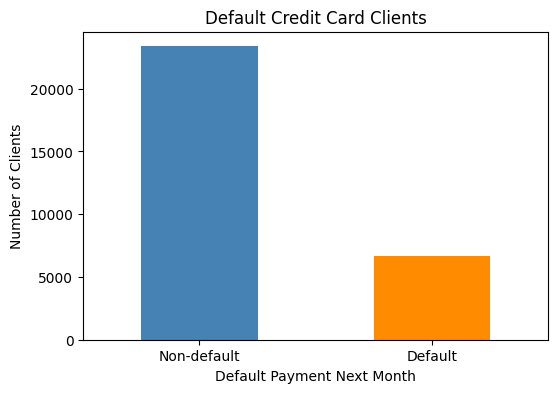

In [10]:
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar", color = ["steelblue", "darkorange"])

plt.title("Default Credit Card Clients")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Clients")
plt.xticks(ticks=[0, 1], labels=["Non-default", "Default"], rotation=0)

plt.show()

The target variable is imbalanced, with non-default customers representing the majority of observations. This imbalance is common in credit risk datasets, where default events are relatively rare compared with normal repayment behavior.

Therefore, evaluation metrics such as ROC-AUC, Recall, and calibration performance are considered more appropriate than accuracy alone.

In [11]:
# =========================
# 2.2 Credit Limit Distribution
# =========================

df["LIMIT_BAL"].describe()

count      30,000.0000
mean      167,484.3227
std       129,747.6616
min        10,000.0000
25%        50,000.0000
50%       140,000.0000
75%       240,000.0000
max     1,000,000.0000
Name: LIMIT_BAL, dtype: float64

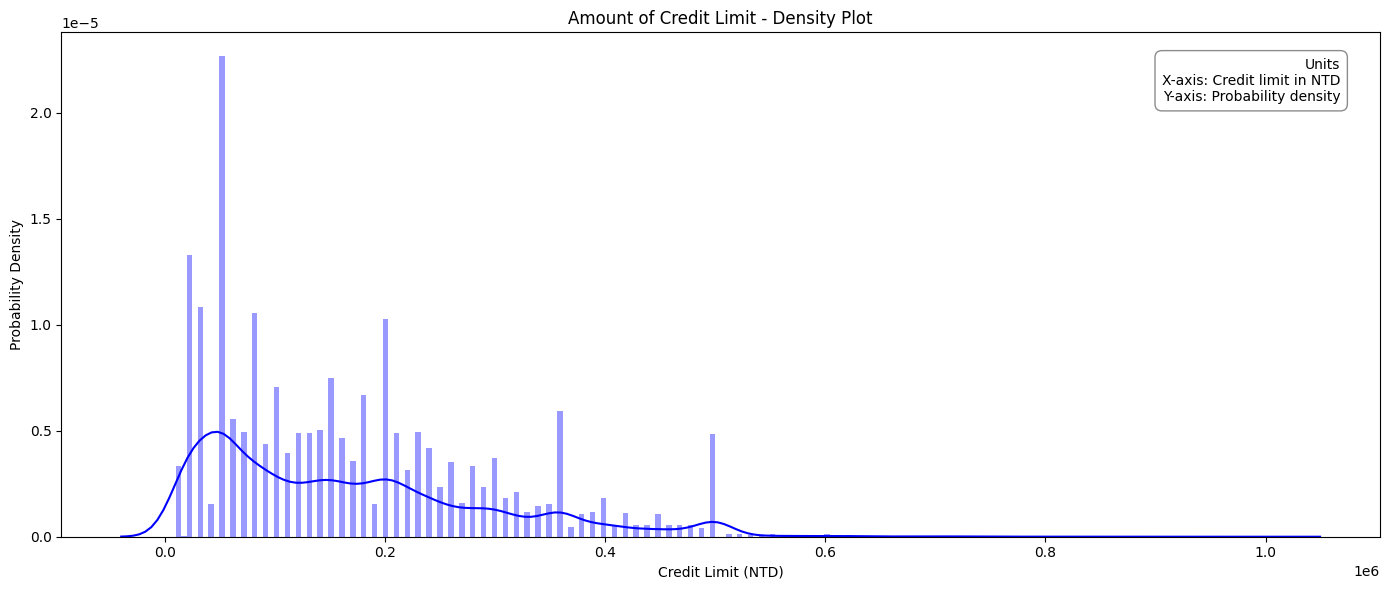

In [12]:
plt.figure(figsize=(14, 6))

ax = sns.distplot(
    df["LIMIT_BAL"],
    kde=True,
    bins=200,
    color="blue"
)

ax.set_title("Amount of Credit Limit - Density Plot")
ax.set_xlabel("Credit Limit (NTD)")
ax.set_ylabel("Probability Density")

ax.text(
    0.97,
    0.95,
    "Units\n"
    "X-axis: Credit limit in NTD\n"
    "Y-axis: Probability density",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()


`LIMIT_BAL` represents the approved credit limit assigned to each customer by the financial institution.

The x-axis shows the credit limit amount in New Taiwan Dollars (NTD). The scientific notation on the axis means:

- `0.2 × 10^6` = 200,000 NTD
- `0.5 × 10^6` = 500,000 NTD
- `1.0 × 10^6` = 1,000,000 NTD

The distribution is highly right-skewed, indicating that most customers receive relatively lower credit limits, while a smaller group of customers has substantially higher assigned credit capacity.

From a credit risk perspective, `LIMIT_BAL` represents the customer's approved borrowing capacity rather than the actual outstanding exposure. Therefore, it is used as a credit capacity indicator in the model. For Expected Loss calculation, `BILL_AMT1` is selected as a simplified proxy for Exposure at Default (EAD) because it better reflects the customer's current outstanding balance.

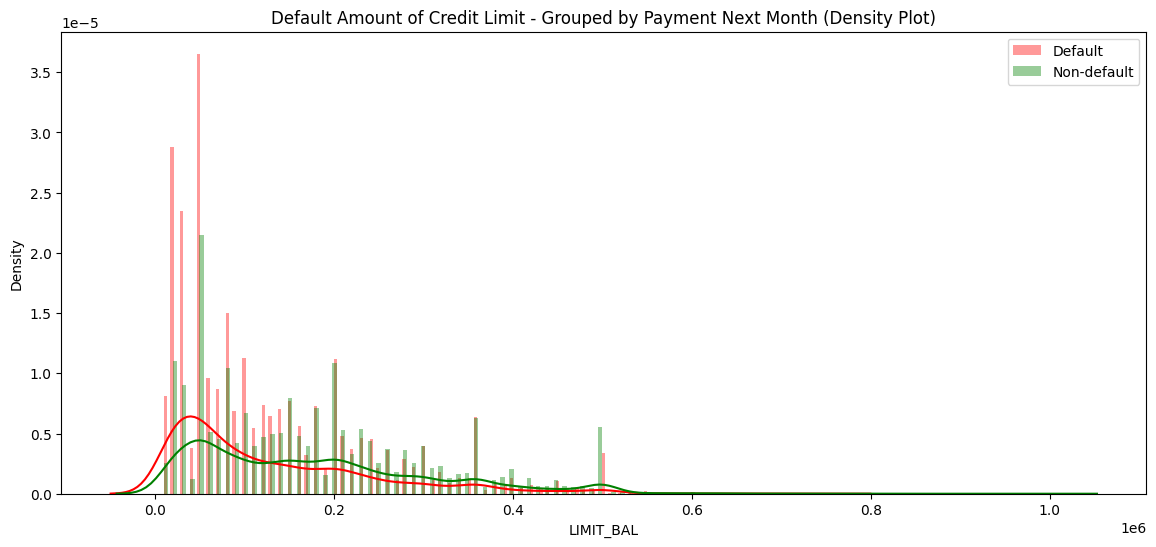

In [13]:
# =========================
# 2.3 Credit Limit by Default Status 
# =========================

class_0 = df.loc[df[target_col] == 0, "LIMIT_BAL"]
class_1 = df.loc[df[target_col] == 1, "LIMIT_BAL"]

plt.figure(figsize=(14, 6))

plt.title("Default Amount of Credit Limit - Grouped by Payment Next Month (Density Plot)")

sns.set_color_codes("pastel")

sns.distplot(
    class_1,
    kde=True,
    bins=200,
    color="red",
    label="Default"
)

sns.distplot(
    class_0,
    kde=True,
    bins=200,
    color="green",
    label="Non-default"
)

plt.xlabel("LIMIT_BAL")
plt.ylabel("Density")
plt.legend()

plt.show()


This density plot compares the distribution of assigned credit limits (`LIMIT_BAL`) between default and non-default customers.

The x-axis represents the approved credit limit in New Taiwan Dollars (NTD), while the y-axis represents probability density. A higher density indicates a higher concentration of customers within a specific credit limit range rather than the absolute number of customers.

The distributions show that default customers are more concentrated in the lower credit limit range compared with non-default customers. This suggests that customers with relatively lower assigned credit limits may represent a higher-risk segment in this dataset.

However, the two distributions overlap substantially across most credit limit ranges, indicating that `LIMIT_BAL` alone is not sufficient to distinguish default and non-default customers. Credit limit should therefore be considered together with other risk-related variables, particularly repayment behavior (`PAY_0` - `PAY_6`), bill amounts, and payment history.

From a credit risk perspective, `LIMIT_BAL` mainly reflects the customer's approved borrowing capacity rather than actual outstanding exposure. Therefore, it is used as a credit profile indicator in the model, while `BILL_AMT1` is later considered as a simplified proxy for Exposure at Default (EAD) in Expected Loss estimation.

In [14]:
# =========================
# 2.4 Credit Limit by Default Status
# =========================

df.groupby(target_col)["LIMIT_BAL"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,"23,364.0000","178,099.7261","131,628.3597","10,000.0000","70,000.0000","150,000.0000","250,000.0000","1,000,000.0000"
1,"6,636.0000","130,109.6564","115,378.5406","10,000.0000","50,000.0000","90,000.0000","200,000.0000","740,000.0000"


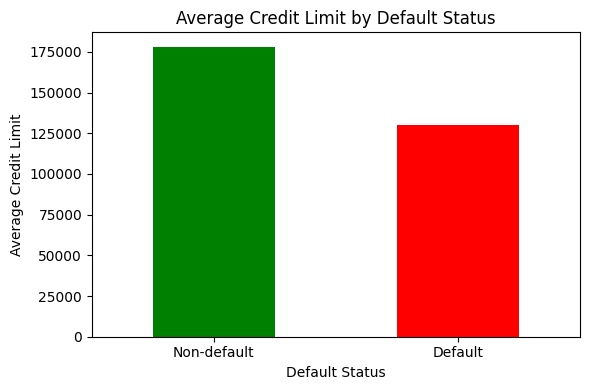

In [15]:
limit_default_summary = df.groupby(target_col)["LIMIT_BAL"].mean()

plt.figure(figsize=(6, 4))

limit_default_summary.plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Average Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Average Credit Limit")
plt.xticks(ticks=[0, 1], labels=["Non-default", "Default"], rotation=0)

plt.tight_layout()
plt.show()

Credit limit differs between default and non-default clients. Although `LIMIT_BAL` is not used as the main EAD proxy in the final Expected Loss calculation, it remains useful for understanding customer credit capacity and for sensitivity comparison.

In [16]:
# =========================
# 2.5 Default Rate by Demographic Variables
# =========================

def default_rate_by_category(data, category_col, target_col="default"):
    summary = (
        data.groupby(category_col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
        .sort_index()
    )

    display(summary)

    plt.figure(figsize=(7, 4))
    summary["default_rate"].plot(kind="bar")
    plt.title(f"Default Rate by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel("Default Rate")
    plt.xticks(rotation=0)
    plt.show()

,count,default_rate
SEX,,
1,11888,0.2417
2,18112,0.2078


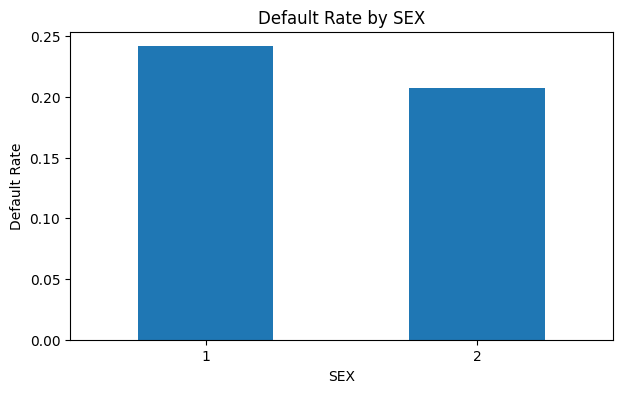

,count,default_rate
EDUCATION,,
0,14,0.0000
1,10585,0.1923
2,14030,0.2373
3,4917,0.2516
4,123,0.0569
5,280,0.0643
6,51,0.1569


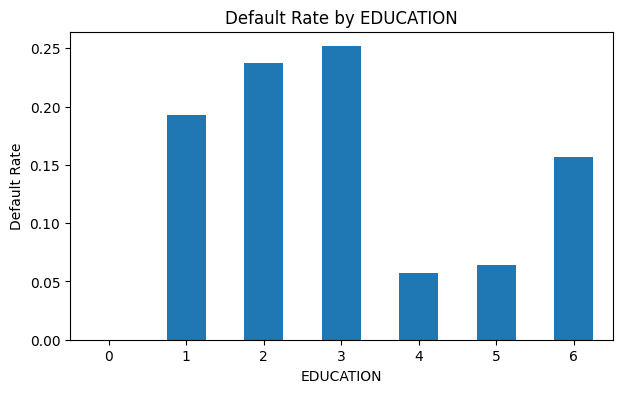

,count,default_rate
MARRIAGE,,
0,54,0.0926
1,13659,0.2347
2,15964,0.2093
3,323,0.2601


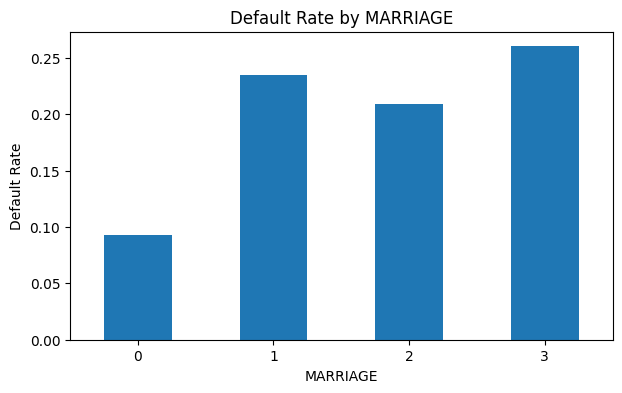

In [17]:
default_rate_by_category(df, "SEX", target_col)
default_rate_by_category(df, "EDUCATION", target_col)
default_rate_by_category(df, "MARRIAGE", target_col)

In [18]:
# =========================
# 2.6 Default Rate by Repayment Status
# =========================

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_status_cols:
    print(f"\nDefault rate by {col}")
    summary = (
        df.groupby(col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
        .sort_index()
    )
    display(summary)


Default rate by PAY_0


,count,default_rate
PAY_0,,
-2,2759,0.1323
-1,5686,0.1678
0,14737,0.1281
1,3688,0.3395
2,2667,0.6914
3,322,0.7578
4,76,0.6842
5,26,0.5000
6,11,0.5455



Default rate by PAY_2


,count,default_rate
PAY_2,,
-2,3782,0.1827
-1,6050,0.1597
0,15730,0.1591
1,28,0.1786
2,3927,0.5561
3,326,0.6166
4,99,0.5051
5,25,0.6000
6,12,0.7500



Default rate by PAY_3


...

,count,default_rate
PAY_4,,
-2,4348,0.1925
-1,5687,0.1590
0,16455,0.1833
1,2,0.5000
2,3159,0.5233
3,180,0.6111
4,69,0.6667
5,35,0.5143
6,5,0.4000



Default rate by PAY_5


,count,default_rate
PAY_5,,
-2,4546,0.1969
-1,5539,0.1619
0,16947,0.1885
2,2626,0.5419
3,178,0.6348
4,84,0.6071
5,17,0.5882
6,4,0.7500
7,58,0.8276



Default rate by PAY_6


,count,default_rate
PAY_6,,
-2,4895,0.2004
-1,5740,0.1699
0,16286,0.1884
2,2766,0.5065
3,184,0.6413
4,49,0.6327
5,13,0.5385
6,19,0.7368
7,46,0.8261


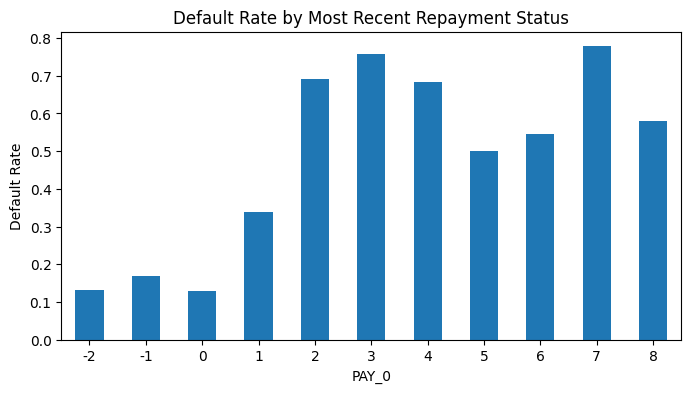

In [19]:
pay0_default_rate = df.groupby("PAY_0")[target_col].mean().sort_index()

plt.figure(figsize=(8, 4))
pay0_default_rate.plot(kind="bar")
plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

In [20]:
# =========================
# 2.7 Correlation among Bill Amount Variables
# =========================

bill_amt_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

bill_corr = df[bill_amt_cols].corr()
bill_corr

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.0000,0.9515,0.8923,0.8603,0.8298,0.8027
BILL_AMT2,0.9515,1.0000,0.9283,0.8925,0.8598,0.8316
BILL_AMT3,0.8923,0.9283,1.0000,0.9240,0.8839,0.8533
BILL_AMT4,0.8603,0.8925,0.9240,1.0000,0.9401,0.9009
BILL_AMT5,0.8298,0.8598,0.8839,0.9401,1.0000,0.9462
BILL_AMT6,0.8027,0.8316,0.8533,0.9009,0.9462,1.0000


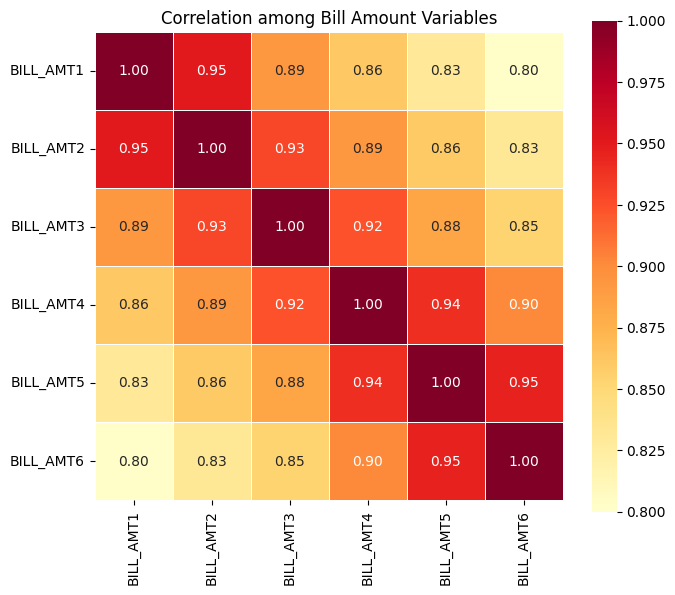

In [21]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    bill_corr,
    annot=True,          
    fmt=".2f",
    cmap="YlOrRd",      
    vmin=0.8, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Bill Amount Variables")
plt.tight_layout()
plt.show()

In [22]:
# =========================
# 2.8 Correlation among Payment Amount Variables
# =========================

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

pay_amt_corr = df[pay_amt_cols].corr()
pay_amt_corr

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
PAY_AMT1,1.0000,0.2856,0.2522,0.1996,0.1485,0.1857
PAY_AMT2,0.2856,1.0000,0.2448,0.1801,0.1809,0.1576
PAY_AMT3,0.2522,0.2448,1.0000,0.2163,0.1592,0.1627
PAY_AMT4,0.1996,0.1801,0.2163,1.0000,0.1518,0.1578
PAY_AMT5,0.1485,0.1809,0.1592,0.1518,1.0000,0.1549
PAY_AMT6,0.1857,0.1576,0.1627,0.1578,0.1549,1.0000


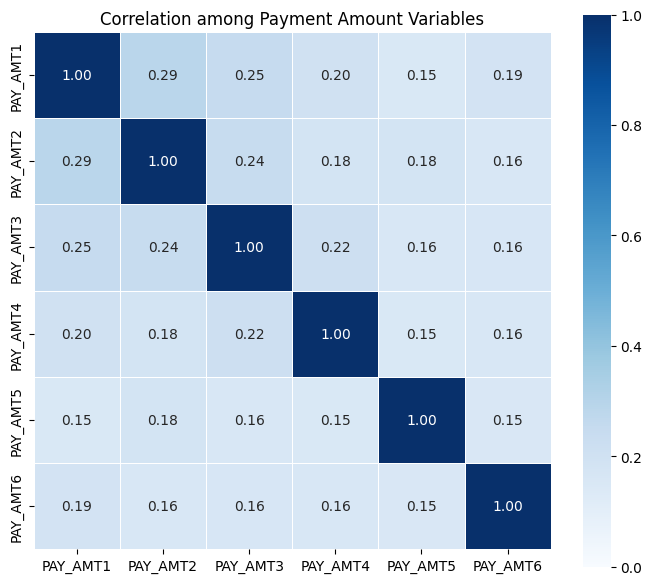

In [23]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    pay_amt_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Payment Amount Variables")
plt.tight_layout()
plt.show()

In [24]:
# =========================
# 2.9 Correlation among Repayment Status Variables
# =========================

pay_status_corr = df[pay_status_cols].corr()
pay_status_corr

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
PAY_0,1.0000,0.6722,0.5742,0.5388,0.5094,0.4746
PAY_2,0.6722,1.0000,0.7666,0.6621,0.6228,0.5755
PAY_3,0.5742,0.7666,1.0000,0.7774,0.6868,0.6327
PAY_4,0.5388,0.6621,0.7774,1.0000,0.8198,0.7164
PAY_5,0.5094,0.6228,0.6868,0.8198,1.0000,0.8169
PAY_6,0.4746,0.5755,0.6327,0.7164,0.8169,1.0000


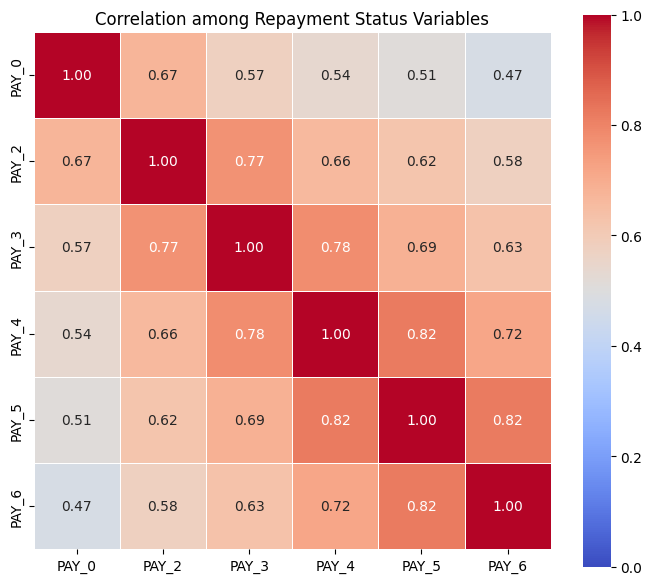

In [25]:

plt.figure(figsize=(7, 6))
sns.heatmap(
    pay_status_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Repayment Status Variables")
plt.tight_layout()
plt.show()

### Multicollinearity Check Using VIF

Variance Inflation Factor (VIF) is used to assess multicollinearity among the predictor variables.

High VIF values indicate that a predictor can be largely explained by the remaining predictors, which may inflate coefficient variance and reduce the stability and interpretability of the Logistic Regression model.

As a general guideline:

- VIF below 5 is typically acceptable.
- VIF between 5 and 10 warrants review.
- VIF above 10 may indicate severe multicollinearity.

The VIF analysis is used mainly to support the interpretability of the Logistic Regression baseline rather than as a strict feature-selection rule for tree-based models.

In [26]:
# =========================
# 2.10 Initial VIF Check on Raw Numeric Variables
# =========================

numeric_features_for_vif = df.select_dtypes(
    include=["int64", "float64"]
).drop(
    columns=["ID", target_col],
    errors="ignore"
)

# Remove columns with only one unique value
numeric_features_for_vif = numeric_features_for_vif.loc[
    :,
    numeric_features_for_vif.nunique() > 1
]

print("Number of numeric features used for VIF:", numeric_features_for_vif.shape[1])

numeric_features_for_vif.head()

Number of numeric features used for VIF: 23


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [27]:

imputer = SimpleImputer(strategy="median")
X_vif_imputed = imputer.fit_transform(numeric_features_for_vif)

# Scale variables for numerical stability
scaler = StandardScaler()
X_vif_scaled = scaler.fit_transform(X_vif_imputed)

vif_data = pd.DataFrame({
    "feature": numeric_features_for_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled, i)
        for i in range(X_vif_scaled.shape[1])
    ]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data

,feature,VIF
0,BILL_AMT2,25.8649
1,BILL_AMT5,24.9967
2,BILL_AMT3,21.7757
3,BILL_AMT4,20.3468
4,BILL_AMT6,15.0248
5,BILL_AMT1,14.0327
6,PAY_5,4.7251
7,PAY_4,4.2874
8,PAY_3,3.6575
9,PAY_6,3.2562


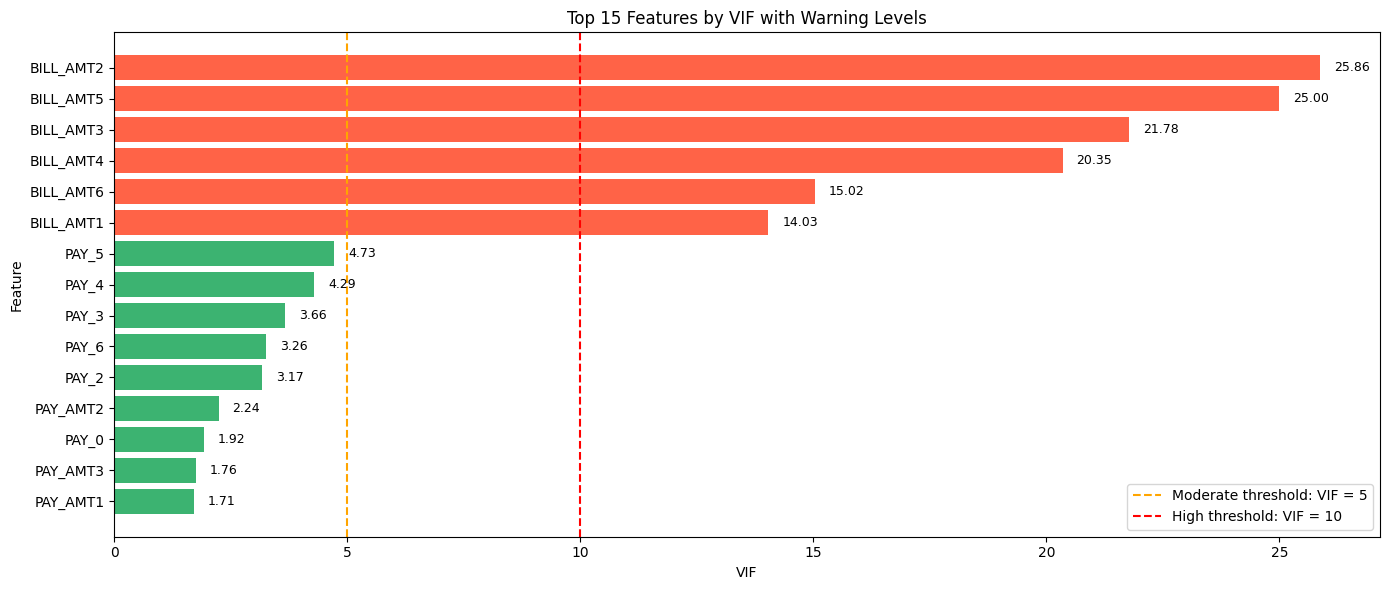

In [28]:
def classify_vif(vif):
    if vif < 5:
        return "Low"
    elif vif < 10:
        return "Moderate"
    else:
        return "High"

# Add VIF warning level
vif_data["VIF_Level"] = vif_data["VIF"].apply(classify_vif)

# Select top 15 highest VIF features
top_vif = vif_data.head(15).sort_values("VIF")

# Color mapping
color_map = {
    "Low": "mediumseagreen",
    "Moderate": "orange",
    "High": "tomato"
}

bar_colors = top_vif["VIF_Level"].map(color_map)

plt.figure(figsize=(14, 6))

bars = plt.barh(
    top_vif["feature"],
    top_vif["VIF"],
    color=bar_colors
)

# Warning threshold lines
plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Moderate threshold: VIF = 5"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="High threshold: VIF = 10"
)

# Add VIF value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.title("Top 15 Features by VIF with Warning Levels")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Multicollinearity Assessment

The correlation matrix shows that the monthly bill amount variables (`BILL_AMT1` to `BILL_AMT6`) are strongly correlated with one another, with pairwise correlation coefficients ranging approximately from 0.80 to 0.95.

This pattern is expected because the six variables represent the same customer's outstanding credit card balance across consecutive months. Customers with high balances in one month are therefore likely to continue having relatively high balances in nearby months.

The VIF results confirm that this strong correlation creates substantial multicollinearity:

- `BILL_AMT2` has the highest VIF at approximately 25.86.
- `BILL_AMT5`, `BILL_AMT3`, and `BILL_AMT4` also have VIF values above 20.
- All six monthly bill variables have VIF values above 10.

These results indicate that the bill amount variables contain considerable overlapping information. Including all six variables simultaneously in Logistic Regression may inflate coefficient variance, reduce coefficient stability, and make the individual effects of each monthly balance difficult to interpret.

By contrast, most repayment-status, payment-amount, demographic, and credit-limit variables have VIF values below 5, suggesting that multicollinearity is mainly concentrated within the monthly bill amount variables.

To improve the stability and interpretability of the Logistic Regression baseline, the six highly correlated bill variables should not all be retained without further consideration. A reduced specification may keep a recent balance measure such as `BILL_AMT1`, replace the monthly variables with an aggregated feature such as average bill amount, or use regularization to limit coefficient instability.

This VIF assessment is primarily relevant to Logistic Regression. Tree-based models such as Random Forest, XGBoost, and LightGBM are less sensitive to multicollinearity in terms of predictive performance, although correlated variables may still divide or distort feature importance.

In [29]:
# =========================
# 2.11 Correlation with Default
# =========================

corr_with_default = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)

corr_with_default

default      1.0000
PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
EDUCATION    0.0280
AGE          0.0139
BILL_AMT6   -0.0054
BILL_AMT5   -0.0068
BILL_AMT4   -0.0102
ID          -0.0140
BILL_AMT3   -0.0141
BILL_AMT2   -0.0142
BILL_AMT1   -0.0196
MARRIAGE    -0.0243
SEX         -0.0400
PAY_AMT6    -0.0532
PAY_AMT5    -0.0551
PAY_AMT3    -0.0563
PAY_AMT4    -0.0568
PAY_AMT2    -0.0586
PAY_AMT1    -0.0729
LIMIT_BAL   -0.1535
Name: default, dtype: float64

### Correlation with Default

The correlation analysis shows that repayment status variables are the strongest linear predictors of default.

`PAY_0` has the highest positive correlation with default at approximately **0.325**, followed by `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, and `PAY_6`. This indicates that customers with more severe or persistent repayment delays are more likely to default in the following month.

The declining correlation from `PAY_0` to `PAY_6` also suggests that more recent repayment behavior contains stronger predictive information than older payment history. In other words, the latest delinquency status is more relevant to short-term default risk.

By contrast, the payment amount variables (`PAY_AMT1` to `PAY_AMT6`) show small negative correlations with default. This implies that customers making larger repayments tend to have a lower probability of default, although the strength of these relationships is relatively weak.

`LIMIT_BAL` has the strongest negative correlation among the displayed variables at approximately **-0.154**. Customers with higher approved credit limits appear to have lower default rates on average, possibly because higher limits are often granted to borrowers with stronger credit profiles. However, this relationship should not be interpreted as causal.

Demographic variables such as `SEX` and `EDUCATION` show only weak correlations with default, suggesting that repayment behavior provides substantially more useful predictive information than basic demographic characteristics.

Overall, the results indicate that **recent repayment delinquency is the most important linear risk signal**, while credit limit and repayment amounts provide additional but weaker information.

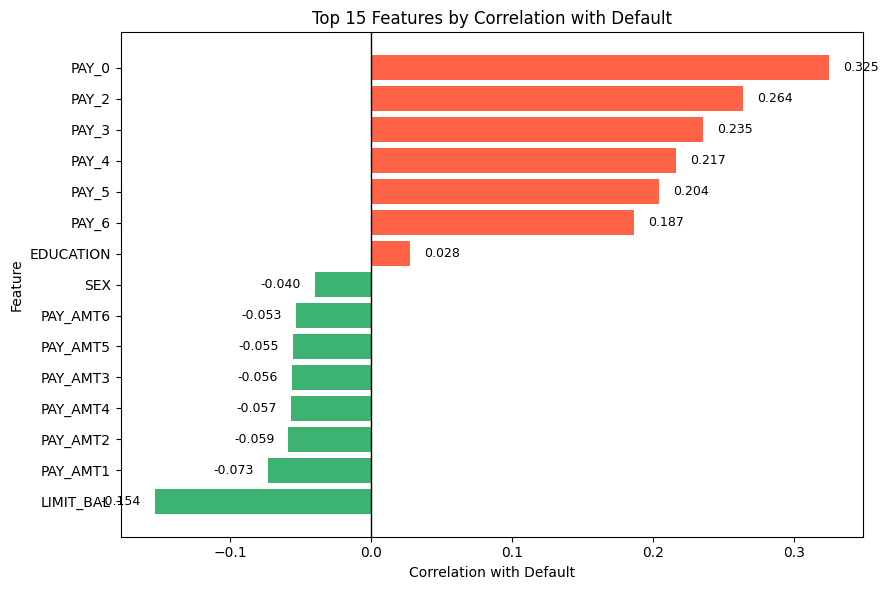

In [30]:
corr_with_default = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
)

top_corr = (
    corr_with_default
    .reindex(corr_with_default.abs().sort_values(ascending=False).head(15).index)
    .sort_values()
)

colors = [
    "tomato" if value > 0 else "mediumseagreen"
    for value in top_corr
]

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_corr.index,
    top_corr.values,
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Top 15 Features by Correlation with Default")
plt.xlabel("Correlation with Default")
plt.ylabel("Feature")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01 if width > 0 else width - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [31]:
# =========================
# 2.12 Behavior Feature Engineering 
# =========================


The original dataset contains monthly repayment status, bill amount, and payment amount variables for the past six months. To summarize customer behavior over time, several behavioral features are created.

| Feature | Formula | Interpretation |
|---|---|---|
| `avg_pay_status` | Average of `PAY_0`, `PAY_2`, ..., `PAY_6` | Measures the customer's average repayment delay over the past six months |
| `avg_bill_amt` | Average of `BILL_AMT1`, ..., `BILL_AMT6` | Measures the customer's average outstanding bill amount |
| `avg_pay_amt` | Average of `PAY_AMT1`, ..., `PAY_AMT6` | Measures the customer's average repayment amount |
| `credit_utilization` | `avg_bill_amt / LIMIT_BAL` | Measures how much of the credit limit is being used |
| `payment_to_bill_ratio` | `avg_pay_amt / avg_bill_amt` | Measures how much the customer repays relative to the outstanding bill |

These features are designed to capture repayment behavior, credit usage, and repayment capacity, which are important signals for Probability of Default modeling.

In [32]:
df["avg_pay_status"] = df[pay_status_cols].mean(axis=1)
df["avg_bill_amt"] = df[bill_amt_cols].mean(axis=1)
df["avg_pay_amt"] = df[pay_amt_cols].mean(axis=1)

df["credit_utilization"] = df["avg_bill_amt"] / df["LIMIT_BAL"]

df["payment_to_bill_ratio"] = (
    df["avg_pay_amt"] / df["avg_bill_amt"].replace(0, np.nan)
)

df["payment_to_bill_ratio"] = df["payment_to_bill_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

df[
    [
        "avg_pay_status",
        "avg_bill_amt",
        "avg_pay_amt",
        "credit_utilization",
        "payment_to_bill_ratio",
        target_col
    ]
].head()

,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,default
0,-0.3333,"1,284.0000",114.8333,0.0642,0.0894,1
1,0.5000,"2,846.1667",833.3333,0.0237,0.2928,1
2,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084,0
3,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363,0
4,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401,0


In [33]:
behavior_summary = df.groupby(target_col)[
    [
        "avg_pay_status",
        "avg_bill_amt",
        "avg_pay_amt",
        "credit_utilization",
        "payment_to_bill_ratio"
    ]
].median()

behavior_summary

,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio
default,,,,,
0,0.0000,"21,443.4167","2,754.0000",0.2416,0.1175
1,0.3333,"19,781.3333","1,612.4167",0.4627,0.0590


## 3. Data Processing and Logistic Regression Baseline

This section prepares the dataset for Probability of Default modeling and builds a baseline Logistic Regression model.

Logistic Regression is used as the baseline model because it is interpretable and commonly used in credit risk modeling. The model output is interpreted as borrower-level Probability of Default (PD).

To reduce multicollinearity and improve model interpretability, the modeling dataset uses a reduced feature set instead of all raw monthly variables.

The original monthly bill amount variables (`BILL`), payment amount variables (`PAY`), and older repayment status variables (`PAY_ATM`) are highly correlated with each other. Therefore, they are summarized into engineered behavior features.

The final modeling feature set keeps:

- Demographic variables: `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` (their numeric codes represent groups rather than continuous quantities while the remaining variables are treated as numeric predictors.)
- Credit exposure variable: `LIMIT_BAL`
- Recent repayment status: `PAY_0`
- Engineered behavior features: `avg_pay_status`, `avg_bill_amt`, `avg_pay_amt`, `credit_utilization`, `payment_to_bill_ratio`

`PAY_0` is retained because recent repayment behavior is highly relevant for next-month default risk. Other monthly variables are excluded to make the model more stable and easier to explain.

In [34]:
# =========================
# 3.1 Create Reduced Modeling Dataset
# =========================

df_model = df.copy()

# Replace infinite values with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Group undocumented education categories into 'Others'
df_model["EDUCATION"] = df_model["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Group undocumented marriage category into 'Others'
df_model["MARRIAGE"] = df_model["MARRIAGE"].replace({
    0: 3
})

# Explicitly select the final modeling features
modeling_features = [
    # Demographics and exposure
    "LIMIT_BAL",
    "AGE",
    "SEX",
    "EDUCATION",
    "MARRIAGE",

    # Most recent repayment status
    "PAY_0",

    # Engineered behavior features
    "avg_pay_status",
    "avg_bill_amt",
    "avg_pay_amt",
    "credit_utilization",
    "payment_to_bill_ratio"
]

# Keep only ID, selected features, and target in the modeling dataset
df_model = df_model[["ID"] + modeling_features + [target_col]].copy()

print("EDUCATION values:", sorted(df_model["EDUCATION"].unique()))
print("MARRIAGE values :", sorted(df_model["MARRIAGE"].unique()))
print("Modeling dataset shape:", df_model.shape)

print("\nFeatures selected for modeling:")
for feature in modeling_features:
    print("-", feature)

display(df_model.head())

EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values : [np.int64(1), np.int64(2), np.int64(3)]
Modeling dataset shape: (30000, 13)

Features selected for modeling:
- LIMIT_BAL
- AGE
- SEX
- EDUCATION
- MARRIAGE
- PAY_0
- avg_pay_status
- avg_bill_amt
- avg_pay_amt
- credit_utilization
- payment_to_bill_ratio


,ID,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,default
0,1,20000,24,2,2,1,2,-0.3333,"1,284.0000",114.8333,0.0642,0.0894,1
1,2,120000,26,2,2,2,-1,0.5000,"2,846.1667",833.3333,0.0237,0.2928,1
2,3,90000,34,2,2,2,0,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084,0
3,4,50000,37,2,2,1,0,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363,0
4,5,50000,57,1,2,1,-1,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401,0


In [35]:
# =========================
# 3.2 Define Features and Target
# =========================

X = df_model[modeling_features].copy()
y = df_model[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (30000, 11)
y shape: (30000,)


,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio
0,20000,24,2,2,1,2,-0.3333,"1,284.0000",114.8333,0.0642,0.0894
1,120000,26,2,2,2,-1,0.5000,"2,846.1667",833.3333,0.0237,0.2928
2,90000,34,2,2,2,0,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084
3,50000,37,2,2,1,0,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363
4,50000,57,1,2,1,-1,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401


The `ID` column is removed because it is only a customer identifier and does not contain predictive information. The target variable is `default`, while the remaining variables are used as model features.

In [36]:
# =========================
# 3.3 Define Numeric and Categorical Features
# =========================

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_features = [
    feature for feature in modeling_features
    if feature not in categorical_features
]

print("Numeric features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

Numeric features:
- LIMIT_BAL
- AGE
- PAY_0
- avg_pay_status
- avg_bill_amt
- avg_pay_amt
- credit_utilization
- payment_to_bill_ratio

Categorical features:
- SEX
- EDUCATION
- MARRIAGE


In [37]:
# =========================
# 3.4 VIF on Final Modeling Features
# =========================

X_vif = df_model[numeric_features].copy()

# Replace infinite values with NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

# Fill missing values with median
X_vif = X_vif.fillna(X_vif.median())

# Scale variables for numerical stability
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=numeric_features
)

vif_data = pd.DataFrame({
    "feature": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_data)

print("VIF check completed on final numeric modeling features.")

,feature,VIF
0,credit_utilization,3.0159
1,avg_pay_status,2.7074
2,avg_bill_amt,2.6608
3,PAY_0,2.2435
4,LIMIT_BAL,2.2389
5,avg_pay_amt,1.2455
6,AGE,1.0227
7,payment_to_bill_ratio,1.0028


VIF check completed on final numeric modeling features.


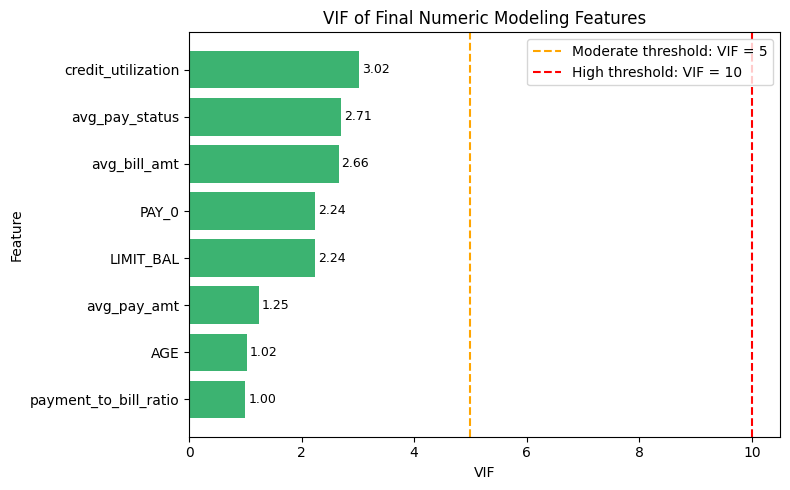

In [38]:

vif_plot = vif_data.sort_values("VIF", ascending=True)

def assign_vif_color(vif):
    if vif >= 10:
        return "tomato"
    elif vif >= 5:
        return "orange"
    else:
        return "mediumseagreen"

colors = vif_plot["VIF"].apply(assign_vif_color)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    vif_plot["feature"],
    vif_plot["VIF"],
    color=colors
)

plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    label="Moderate threshold: VIF = 5"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    label="High threshold: VIF = 10"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.title("VIF of Final Numeric Modeling Features")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

### VIF Assessment of the Final Modeling Features

The VIF results indicate that the reduced feature set no longer suffers from serious multicollinearity.

All numeric predictors have VIF values below the commonly used threshold of 5. The highest value is observed for `credit_utilization` at approximately **3.02**, followed by `avg_pay_status` at **2.71** and `avg_bill_amt` at **2.66**. These values suggest moderate but acceptable overlap in information.

The variables `PAY_0` and `LIMIT_BAL` both have VIF values of approximately **2.24**, while `avg_pay_amt`, `AGE`, and `payment_to_bill_ratio` are close to 1, indicating little multicollinearity.

Compared with the original monthly bill variables, whose VIF values were above 10 and in several cases above 20, the engineered and reduced feature set substantially improves model stability and interpretability.

Therefore, the final numeric predictors are considered suitable for the Logistic Regression baseline without requiring further variable removal based on VIF alone.

**Conclusion:** The reduced feature specification successfully controls multicollinearity, with all VIF values remaining below 5.

In [39]:
# =========================
# 3.5 Train/Test Split (70/30)
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21000, 11)
X_test shape: (9000, 11)
y_train shape: (21000,)
y_test shape: (9000,)


In [40]:
# Check default rate in train and test sets

split_default_rate = pd.DataFrame({
    "train_default_rate": y_train.value_counts(normalize=True).sort_index(),
    "test_default_rate": y_test.value_counts(normalize=True).sort_index()
})

split_default_rate

,train_default_rate,test_default_rate
default,,
0,0.7788,0.7788
1,0.2212,0.2212


### Create Model-Training and Calibration Sets

The original training sample is further divided into two subsets:

- a **model-training set**, used to fit the predictive model;
- a **calibration set**, used to adjust the predicted probabilities.

The test set remains untouched and is reserved for final out-of-sample evaluation.

This separation is important because a model can rank customers correctly while still producing poorly calibrated probabilities. Since the estimated Probability of Default (PD) is later used in Expected Loss calculations, the predicted probabilities should be aligned as closely as possible with observed default frequencies.

#### Split configuration

`test_size=0.25` assigns 25% of the existing training set to the calibration sample, while the remaining 75% is used for model fitting.

For example, if the original dataset was first divided into:

- 70% training data;
- 30% test data;

then the final allocation would be approximately:

- model training: \(70\% \times 75\% = 52.5\%\);
- calibration: \(70\% \times 25\% = 17.5\%\);
- test: 30%.

The exact proportions depend on the initial train-test split used earlier in the notebook.

`random_state=42` ensures reproducibility by keeping the same observations in each subset whenever the notebook is rerun. Without a fixed random state, different customers could be assigned to the training and calibration sets on each run, causing the results to vary.

`stratify=y_train` preserves the default and non-default proportions across the model-training and calibration samples. This is particularly important because the target variable is imbalanced. Without stratification, one subset could contain an unusually high or low default rate, which could make model estimation or probability calibration less reliable.

After the split, the class distribution is checked in the model-training, calibration, and test sets to confirm that the default rate remains approximately consistent across all three samples.

In [41]:
# =========================
# 3.6 Create Model Training and Calibration Sets
# =========================

X_model_train, X_calib, y_model_train, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Model training shape:", X_model_train.shape)
print("Calibration shape:", X_calib.shape)
print("Test shape:", X_test.shape)

print("\nModel training default rate:")
print(y_model_train.value_counts(normalize=True))

print("\nCalibration default rate:")
print(y_calib.value_counts(normalize=True))

print("\nTest default rate:")
print(y_test.value_counts(normalize=True))

Model training shape: (15750, 11)
Calibration shape: (5250, 11)
Test shape: (9000, 11)

Model training default rate:
default
0   0.7788
1   0.2212
Name: proportion, dtype: float64

Calibration default rate:
default
0   0.7789
1   0.2211
Name: proportion, dtype: float64

Test default rate:
default
0   0.7788
1   0.2212
Name: proportion, dtype: float64


### Build the Preprocessing Pipeline

Separate preprocessing pipelines are created for numeric and categorical variables.

For numeric features, missing values are imputed using the median and the variables are standardized. Median imputation is preferred because several monetary variables are right-skewed and may contain extreme values. Standardization places variables with different measurement scales on a comparable scale, which supports stable Logistic Regression estimation.

For categorical features, missing values are replaced with the most frequent category and the variables are transformed using one-hot encoding. The first category is dropped to provide a reference group and reduce redundant dummy variables. Unknown categories are ignored to prevent errors when transforming calibration or test observations.

A `ColumnTransformer` combines both preprocessing procedures and applies each pipeline only to its designated feature group. This approach ensures consistent preprocessing across the training, calibration, and test sets while reducing the risk of data leakage.

In [42]:
# =========================
# 3.7 Build Preprocessing Pipeline
# =========================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [43]:
# =========================
# 3.8 Train Logistic Regression Baseline
# =========================

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)) #Lopp 1000
    ]
)

log_reg_model.fit(X_model_train, y_model_train)

print("Logistic Regression baseline model trained successfully.")

Logistic Regression baseline model trained successfully.


A Logistic Regression model is trained as the baseline PD model. This model learns the relationship between customer characteristics, repayment behavior, credit usage, and the probability of default.

In [44]:
# =========================
# 3.9 Predict Probability of Default
# =========================

y_test_pred = log_reg_model.predict(X_test)

y_test_pd = log_reg_model.predict_proba(X_test)[:, 1]

prediction_results = pd.DataFrame({
    "ID": df_model.loc[X_test.index, "ID"].values,
    "actual_default": y_test.values,
    "predicted_default": y_test_pred,
    "predicted_PD": y_test_pd
})


prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD
0,8942,0,0,0.1873
1,17619,1,0,0.2265
2,27896,0,0,0.1351
3,16104,0,0,0.3048
4,4423,0,0,0.2371


In [45]:
# =========================
# 3.10 Baseline Model Performance
# =========================

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, y_test_pd)
gini = 2 * auc - 1

baseline_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Gini"],
    "Value": [accuracy, precision, recall, f1, auc, gini]
})

baseline_metrics

,Metric,Value
0,Accuracy,0.8072
1,Precision,0.7045
2,Recall,0.2215
3,F1-score,0.3370
4,ROC-AUC,0.7148
5,Gini,0.4297


### Baseline Model Performance

The Logistic Regression baseline achieves an ROC-AUC of **0.7148** and a Gini coefficient of approximately **0.4297**, indicating a reasonable ability to rank higher-risk customers above lower-risk customers.

At the default classification threshold of 0.50, the model records an accuracy of **80.72%** and a precision of **70.45%**. However, recall is only **22.15%**, meaning that the model identifies only a small proportion of customers who actually default.

The relatively high precision but low recall suggests that the 0.50 threshold is conservative. The model produces fewer default alerts, and those alerts are often correct, but many actual default cases are classified as non-default.

In a credit risk context, these false negatives may lead to underestimated borrower risk and potential credit losses. Therefore, the next step is to evaluate alternative classification thresholds and examine the trade-off between recall, precision, and operational review volume.

In [46]:
# Classification report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.89      7009
           1       0.70      0.22      0.34      1991

    accuracy                           0.81      9000
   macro avg       0.76      0.60      0.61      9000
weighted avg       0.79      0.81      0.77      9000



In [47]:
# Confusion matrix

conf_matrix = confusion_matrix(y_test, y_test_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6824,185
Actual Default,1550,441


### ROC Curve Interpretation

The ROC curve evaluates the Logistic Regression model across all possible classification thresholds.

The y-axis represents the True Positive Rate, or default recall, while the x-axis represents the False Positive Rate, which measures the share of non-default customers incorrectly flagged as default.

The model's ROC curve remains above the random-classifier line, indicating that it provides better discrimination than random prediction.

The ROC-AUC of approximately **0.715** suggests that the model has a reasonable ability to rank default customers above non-default customers. More specifically, the model has about a 71.5% probability of assigning a higher risk score to a randomly selected default customer than to a randomly selected non-default customer.

However, the ROC curve also illustrates the trade-off between detecting more defaults and generating more false-positive alerts. Therefore, the final operating threshold should be selected based on business costs and risk-management objectives rather than ROC-AUC alone.

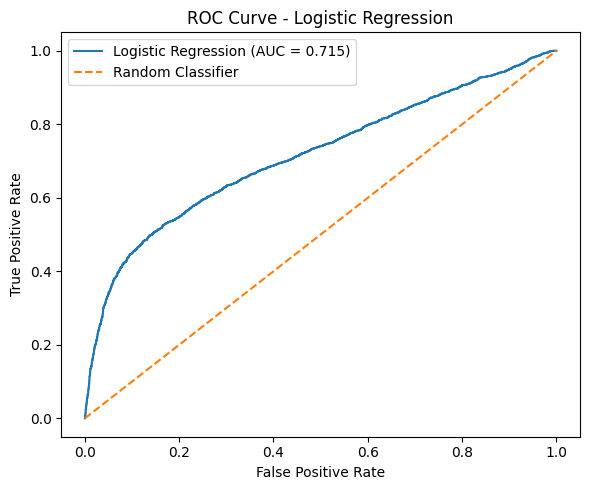

In [48]:
# =========================
# 3.11 ROC Curve — Logistic Regression Baseline
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_test_pd)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation of Logistic Regression Coefficients

The Logistic Regression coefficient table shows the variables that are actually used by the model after preprocessing. Some feature names are different from the original dataset column names because the data has passed through the preprocessing pipeline.

For numeric variables, the prefix `num__` indicates that the variable has passed through the numeric preprocessing pipeline, including missing value imputation and standardization. For example, `LIMIT_BAL` becomes `num__LIMIT_BAL`, and `PAY_0` becomes `num__PAY_0`.

For categorical variables, the prefix `cat__` indicates that the variable has passed through one-hot encoding. For example, the original variable `EDUCATION` is transformed into dummy variables such as `cat__EDUCATION_2`, `cat__EDUCATION_3`, and `cat__EDUCATION_4`.

Conceptually, the Logistic Regression model calculates a risk score as a weighted combination of the selected credit risk features:

$$
risk\_score =
\beta_0
+ \beta_1 LIMIT\_BAL
+ \beta_2 AGE
+ \beta_3 PAY\_0
+ \beta_4 avg\_pay\_status
+ \beta_5 avg\_bill\_amt
+ \beta_6 avg\_pay\_amt
+ \beta_7 credit\_utilization
+ \beta_8 payment\_to\_bill\_ratio
+ \gamma D
$$

where \(D\) represents demographic dummy variables created from `SEX`, `EDUCATION`, and `MARRIAGE` after one-hot encoding.

The risk score is then converted into Probability of Default using the logistic function:

$$
PD = \frac{1}{1 + e^{-risk\_score}}
$$

A positive coefficient increases the risk score and therefore increases the predicted Probability of Default. A negative coefficient decreases the risk score and therefore lowers the predicted Probability of Default.

Since this project focuses on predictive credit risk modeling rather than statistical hypothesis testing, p-values are not reported. Model performance is evaluated using out-of-sample metrics such as ROC-AUC, Gini, precision, recall, F1-score, and threshold analysis.

In [49]:
# =========================
# 3.12 Logistic Regression Coefficients
# =========================

feature_names = log_reg_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg_model.named_steps["model"].coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
11,cat__EDUCATION_4,-1.2437,1.2437
2,num__PAY_0,0.5907,0.5907
5,num__avg_pay_amt,-0.3108,0.3108
3,num__avg_pay_status,0.3037,0.3037
12,cat__MARRIAGE_2,-0.2028,0.2028
10,cat__EDUCATION_3,-0.1829,0.1829
0,num__LIMIT_BAL,-0.1712,0.1712
13,cat__MARRIAGE_3,-0.1363,0.1363
9,cat__EDUCATION_2,-0.1332,0.1332
8,cat__SEX_2,-0.1248,0.1248


### Logistic Regression Coefficient Interpretation

The Logistic Regression coefficients indicate the direction and relative strength of association between each transformed predictor and the estimated default risk, holding the remaining variables constant.

Positive coefficients indicate higher default log-odds, while negative coefficients indicate lower default log-odds. Among the numeric predictors, recent repayment delinquency (`PAY_0`) and average repayment status have positive coefficients, confirming that more severe repayment delays are associated with higher default risk.

Average payment amount and approved credit limit have negative coefficients, suggesting that customers with stronger payment behavior or larger approved credit capacity tend to exhibit lower predicted default risk.

Categorical coefficients are interpreted relative to the omitted reference category created by one-hot encoding. Therefore, their signs and magnitudes should not be interpreted without identifying the corresponding reference group.

Coefficient magnitude is used as a descriptive measure of model influence, but it should not be interpreted as causality. Rare categories, feature scaling, regularization, and remaining correlations may also affect coefficient estimates.

## 4. Model Comparison

The earlier Logistic Regression model is used as an interpretable baseline without class weighting.

For comparative model evaluation, a separate **Balanced Logistic Regression** is defined using `class_weight="balanced"`. This adjustment gives greater importance to the minority default class and generally increases default recall, although precision and overall accuracy may decrease.

The balanced Logistic Regression is compared with three nonlinear tree-based models:

- Random Forest
- XGBoost
- LightGBM

Class imbalance is addressed consistently across the candidate models:

- Logistic Regression, Random Forest, and LightGBM use balanced class weights.
- XGBoost uses `scale_pos_weight`, calculated from the ratio of non-default to default observations in the model-training sample.

The tree-based models are included because they can capture nonlinear relationships and interactions between repayment behavior, credit utilization, payment capacity, and customer characteristics that may not be fully represented by a linear model.

All candidate models use the same preprocessing pipeline and are evaluated on the same data splits. Model performance is compared using ROC-AUC, Gini, precision, recall, and F1-score for the default class.

Cross-validation is also used to verify that model performance remains stable across different training-data partitions rather than being driven by a favorable random split.

In [50]:
# =========================
# 4.1 Import Model Comparison Libraries
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Try importing XGBoost and LightGBM safely

try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available.")
except Exception as e:
    xgboost_available = False
    print("XGBoost is not available.")
    print("Reason:", type(e).__name__)

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
    print("LightGBM is available.")
except Exception as e:
    lightgbm_available = False
    print("LightGBM is not available.")
    print("Reason:", type(e).__name__)

XGBoost is available.
LightGBM is available.


In [51]:
# =========================
# 4.2 Define Candidate Models
# =========================

# Calculate imbalance ratio from model training data for XGBoost
negative_count = (y_model_train == 0).sum()
positive_count = (y_model_train == 1).sum()

scale_pos_weight_value = negative_count / positive_count

print("Non-default count:", negative_count)
print("Default count:", positive_count)
print("Scale_pos_weight:", round(scale_pos_weight_value, 4))

candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
}

if xgboost_available:
    candidate_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight_value
    )

if lightgbm_available:
    candidate_models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )

candidate_models.keys()

Non-default count: 12266
Default count: 3484
Scale_pos_weight: 3.5207


dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'])

In [52]:
# =========================
# 4.3 Train and Evaluate Candidate Models
# =========================

model_results = []
model_predictions = {}

for model_name, model in candidate_models.items():
    
    print(f"Training {model_name}...")
    
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    # Train only on model training set
    model_pipeline.fit(X_model_train, y_model_train)
    
    # Evaluate on untouched test set
    y_pred = model_pipeline.predict(X_test)
    y_pd = model_pipeline.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pd)
    gini = 2 * auc - 1

    model_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision_default": precision,
        "recall_default": recall,
        "f1_default": f1,
        "roc_auc": auc,
        "gini": gini
    })
    
    model_predictions[model_name] = {
        "pipeline": model_pipeline,
        "y_pred": y_pred,
        "y_pd": y_pd
    }

model_comparison = pd.DataFrame(model_results)

model_comparison

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...


,model,accuracy,precision_default,recall_default,f1_default,roc_auc,gini
0,Logistic Regression,0.6740,0.3642,0.6354,0.4630,0.7153,0.4307
1,Random Forest,0.7636,0.4735,0.6148,0.5350,0.7776,0.5551
2,XGBoost,0.7583,0.4656,0.6258,0.5340,0.7765,0.5531
3,LightGBM,0.7564,0.4631,0.6328,0.5348,0.7765,0.5531


In [53]:
# =========================
# 4.3b Cross-Validation Verification (Stratified K-Fold)
# Cross-validation checks whether model performance is stable across different data splits rather than driven by one lucky train-test split.
# =========================

# Cross-validation confirms that train/test results are not due to a
# lucky random split. We run 5-fold CV on the training set only,
# so the test set remains untouched as a final holdout.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for model_name, model in candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_model_train, y_model_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append({
        "model": model_name,
        "cv_auc_mean": scores.mean(),
        "cv_auc_std": scores.std()
    })
    print(f"{model_name}: CV AUC = {scores.mean():.4f} ± {scores.std():.4f}")

cv_comparison = pd.DataFrame(cv_results).sort_values("cv_auc_mean", ascending=False)
cv_comparison

Logistic Regression: CV AUC = 0.7217 ± 0.0054
Random Forest: CV AUC = 0.7780 ± 0.0052
XGBoost: CV AUC = 0.7774 ± 0.0057
LightGBM: CV AUC = 0.7768 ± 0.0046


,model,cv_auc_mean,cv_auc_std
1,Random Forest,0.7780,0.0052
2,XGBoost,0.7774,0.0057
3,LightGBM,0.7768,0.0046
0,Logistic Regression,0.7217,0.0054


In [54]:
# =========================
# 4.4 Sort Models by ROC-AUC
# =========================

model_comparison = model_comparison.sort_values(
    "roc_auc",
    ascending=False
).reset_index(drop=True)

model_comparison

,model,accuracy,precision_default,recall_default,f1_default,roc_auc,gini
0,Random Forest,0.7636,0.4735,0.6148,0.5350,0.7776,0.5551
1,XGBoost,0.7583,0.4656,0.6258,0.5340,0.7765,0.5531
2,LightGBM,0.7564,0.4631,0.6328,0.5348,0.7765,0.5531
3,Logistic Regression,0.6740,0.3642,0.6354,0.4630,0.7153,0.4307


### Model Comparison on the Test Set

The three tree-based models achieve very similar discriminatory performance, with ROC-AUC values around **0.777** and Gini coefficients around **0.555**. Random Forest ranks slightly highest with a ROC-AUC of **0.7776**, although the difference from XGBoost and LightGBM is very small.

Compared with Logistic Regression, the tree-based models provide a clear improvement in ranking performance and F1-score, suggesting that nonlinear relationships and interactions contribute useful predictive information.

Among the tree-based models, LightGBM records the highest default recall at **63.28%**, while Random Forest achieves the highest accuracy, precision, ROC-AUC, and Gini. This reflects the trade-off between detecting more default cases and limiting false-positive alerts.

Overall, Random Forest is selected as the final model because it provides the strongest overall balance of discrimination, precision, recall, and stability. However, the performance differences among Random Forest, XGBoost, and LightGBM are small, so the selection should be interpreted as a slight advantage rather than a clear superiority.

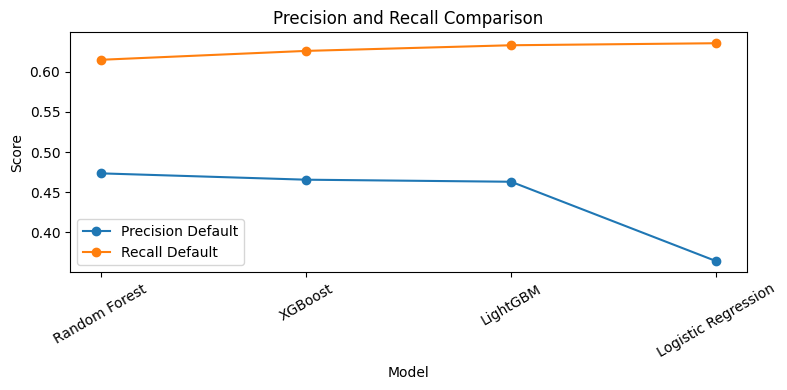

In [55]:
# =========================
# 4.5 Precision and Recall Comparison
# =========================

plt.figure(figsize=(8, 4))

plt.plot(
    model_comparison["model"],
    model_comparison["precision_default"],
    marker="o",
    label="Precision Default"
)

plt.plot(
    model_comparison["model"],
    model_comparison["recall_default"],
    marker="o",
    label="Recall Default"
)

plt.title("Precision and Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

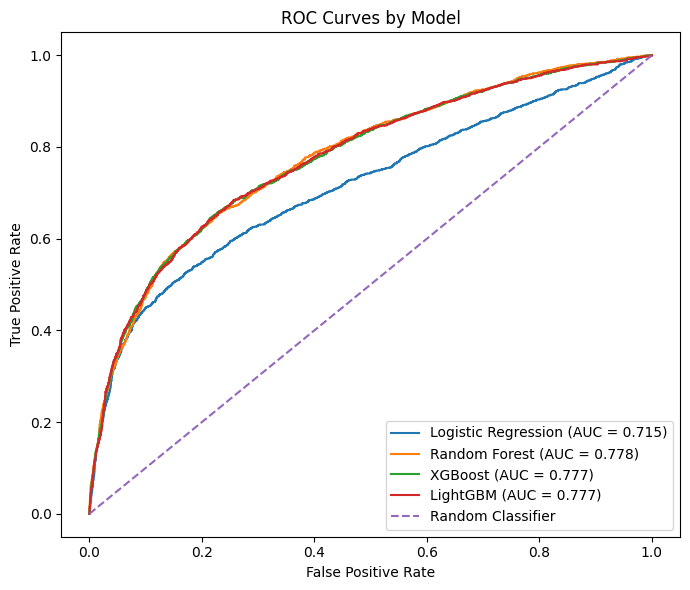

In [56]:
# =========================
# 4.6 ROC Curves for Candidate Models
# =========================

plt.figure(figsize=(7, 6))

for model_name in model_predictions.keys():
    y_pd = model_predictions[model_name]["y_pd"]
    fpr, tpr, thresholds = roc_curve(y_test, y_pd)
    auc_score = roc_auc_score(y_test, y_pd)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curves by Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()
plt.show()

The ROC curves show the trade-off between true positive rate and false positive rate across different thresholds. Models with curves closer to the top-left corner have stronger discriminatory power.

The final model is selected based primarily on ROC-AUC because the main objective of the PD model is to rank borrowers by default risk. Precision and recall are also reviewed to understand the classification trade-off.

## Probability Calibration with Platt Scaling

The selected model is first trained to rank customers by default risk. However, a model can achieve strong discriminatory performance while still producing probabilities that are systematically too high or too low.

This distinction is important in credit risk modeling:

- **Discrimination** evaluates whether higher-risk customers receive higher scores than lower-risk customers.
- **Calibration** evaluates whether the predicted Probability of Default matches the observed default frequency.

For example, if a group of customers receives an average predicted PD of 20%, a well-calibrated model should observe a default rate close to 20% within that group.

Platt Scaling is applied to transform the original model output into a calibrated Probability of Default using an additional logistic function:

$$
\widehat{PD}_{\text{calibrated}}
=
\frac{1}
{1+\exp\left[-\left(Az(x)+B\right)\right]}
$$

where:

- $z(x)$ is the uncalibrated output or score produced by the selected model;
- $A$ and $B$ are calibration parameters estimated from the calibration sample;
- $\widehat{PD}_{\text{calibrated}}$ is the adjusted Probability of Default.

The parameters $A$ and $B$ are learned so that the calibrated probabilities more closely match the observed default frequencies in the calibration set.

This step is particularly important because the candidate models use class-imbalance adjustments. These adjustments improve the detection of default customers, but they may distort the absolute probability estimates and cause the average predicted PD to differ substantially from the actual default rate.

A separate calibration set is therefore used to learn the probability adjustment. The underlying model is trained only on the model-training sample, while the test set remains untouched and is used only for final out-of-sample evaluation.

The purpose of calibration is not primarily to improve ROC-AUC or change the ranking of customers. Instead, it aims to make the predicted PD values more reliable for practical applications such as:

- borrower-level risk assessment;
- risk-band segmentation;
- classification-threshold analysis;
- Expected Loss estimation;
- portfolio stress testing.

**Key distinction:** ROC-AUC measures how well the model ranks customers by risk, while calibration measures whether a predicted PD of, for example, 20% corresponds to an observed default rate close to 20%.

In [57]:
# =========================
# 4.7 Select Final Model
# =========================

# Select the final model using cross-validation results
best_row = cv_comparison.iloc[0]
best_model_name = best_row["model"]
best_auc = best_row["cv_auc_mean"]

benchmark_name = "Logistic Regression"
benchmark_auc = cv_comparison.loc[
    cv_comparison["model"].eq(benchmark_name),
    "cv_auc_mean"
].iloc[0]

auc_improvement = best_auc - benchmark_auc
auc_improvement_threshold = 0.01

final_model_name = (
    benchmark_name
    if auc_improvement < auc_improvement_threshold
    else best_model_name
)

final_results = model_predictions[final_model_name]

final_model = final_results["pipeline"]
final_y_test_pred_uncalibrated = final_results["y_pred"]
final_y_test_pd_uncalibrated = final_results["y_pd"]

print(f"Best model by CV ROC-AUC: {best_model_name} ({best_auc:.4f})")
print(f"Final model selected: {final_model_name}")

Best model by CV ROC-AUC: Random Forest (0.7780)
Final model selected: Random Forest


In [58]:
# =========================
# 4.8 Probability Calibration with Platt Scaling
# =========================

# Extract fitted preprocessor and fitted base model from final pipeline
final_preprocessor = final_model.named_steps["preprocessor"]
final_base_model = final_model.named_steps["model"]

# Transform calibration and test data using the fitted preprocessor
X_calib_transformed = final_preprocessor.transform(X_calib)
X_test_transformed_for_calibration = final_preprocessor.transform(X_test)

# Convert sparse matrix to dense array if needed
if hasattr(X_calib_transformed, "toarray"):
    X_calib_transformed = X_calib_transformed.toarray()

if hasattr(X_test_transformed_for_calibration, "toarray"):
    X_test_transformed_for_calibration = X_test_transformed_for_calibration.toarray()

# Create Platt Scaling calibrator
# Newer scikit-learn versions use FrozenEstimator for already-fitted models.
# Older versions use cv="prefit".
if frozen_estimator_available:
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(final_base_model),
        method="sigmoid"
    )
else:
    calibrated_model = CalibratedClassifierCV(
        final_base_model,
        method="sigmoid",
        cv="prefit"
    )

# Fit calibrator on calibration set only
calibrated_model.fit(X_calib_transformed, y_calib)

# Get calibrated PD on test set
final_y_test_pd = calibrated_model.predict_proba(
    X_test_transformed_for_calibration
)[:, 1]

# Convert calibrated PD into class prediction at 0.5 threshold
final_y_test_pred = (final_y_test_pd >= 0.5).astype(int)

print("Probability calibration completed using Platt Scaling.")
print("Final model:", final_model_name)
print("Average uncalibrated PD:", round(final_y_test_pd_uncalibrated.mean(), 4))
print("Average calibrated PD  :", round(final_y_test_pd.mean(), 4))
print("Actual default rate    :", round(y_test.mean(), 4))

Probability calibration completed using Platt Scaling.
Final model: Random Forest
Average uncalibrated PD: 0.4231
Average calibrated PD  : 0.2208
Actual default rate    : 0.2212


In [59]:
# =========================
# 4.8b Calibration Comparison
# =========================

calibration_comparison = pd.DataFrame({
    "Metric": [
        "Average PD",
        "Actual Default Rate",
        "Brier Score",
        "Log Loss",
        "ROC-AUC",
        "Gini"
    ],
    "Uncalibrated": [
        final_y_test_pd_uncalibrated.mean(),
        y_test.mean(),
        brier_score_loss(y_test, final_y_test_pd_uncalibrated),
        log_loss(y_test, final_y_test_pd_uncalibrated),
        roc_auc_score(y_test, final_y_test_pd_uncalibrated),
        2 * roc_auc_score(y_test, final_y_test_pd_uncalibrated) - 1
    ],
    "Calibrated": [
        final_y_test_pd.mean(),
        y_test.mean(),
        brier_score_loss(y_test, final_y_test_pd),
        log_loss(y_test, final_y_test_pd),
        roc_auc_score(y_test, final_y_test_pd),
        2 * roc_auc_score(y_test, final_y_test_pd) - 1
    ]
})

calibration_comparison

,Metric,Uncalibrated,Calibrated
0,Average PD,0.4231,0.2208
1,Actual Default Rate,0.2212,0.2212
2,Brier Score,0.1788,0.1365
3,Log Loss,0.5428,0.4335
4,ROC-AUC,0.7776,0.7776
5,Gini,0.5551,0.5551


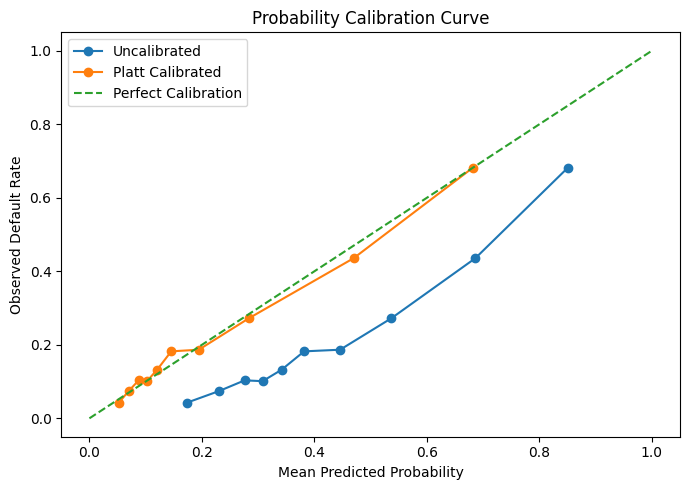

In [60]:
from sklearn.calibration import calibration_curve

prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test,
    final_y_test_pd_uncalibrated,
    n_bins=10,
    strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    final_y_test_pd,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred_uncal,
    prob_true_uncal,
    marker="o",
    label="Uncalibrated"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Platt Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.title("Probability Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# =========================
# 4.9 Final Model Metrics
# =========================

final_auc = roc_auc_score(y_test, final_y_test_pd)
final_gini = 2 * final_auc - 1
final_accuracy = accuracy_score(y_test, final_y_test_pred)
final_precision = precision_score(y_test, final_y_test_pred, zero_division=0)
final_recall = recall_score(y_test, final_y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, final_y_test_pred, zero_division=0)

final_model_metrics = pd.DataFrame({
    "Metric": [
        "Final Model",
        "PD Type",
        "Accuracy",
        "Precision Default",
        "Recall Default",
        "F1 Default",
        "ROC-AUC",
        "Gini"
    ],
    "Value": [
        final_model_name,
        "Calibrated PD - Platt Scaling",
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc,
        final_gini
    ]
})

final_model_metrics

,Metric,Value
0,Final Model,Random Forest
1,PD Type,Calibrated PD - Platt Scaling
2,Accuracy,0.8123
3,Precision Default,0.6216
4,Recall Default,0.3877
5,F1 Default,0.4776
6,ROC-AUC,0.7776
7,Gini,0.5551


In [62]:
# =========================
# 4.10 Final Model Confusion Matrix
# =========================

final_conf_matrix = confusion_matrix(y_test, final_y_test_pred)

final_conf_matrix_df = pd.DataFrame(
    final_conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

final_conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6539,470
Actual Default,1219,772


### Model Explainability

After selecting and calibrating the final model, this section examines how the model generates its predictions.

Global feature importance is used to identify the variables that contribute most to overall model performance, while SHAP analysis is used to evaluate both the magnitude and direction of each feature's effect on predicted Probability of Default.

This step supports model validation, business interpretation, and transparent communication of the main borrower-level risk drivers. The results should be interpreted as predictive associations rather than causal effects.

The confusion matrix shows how the final model classifies default and non-default clients at the default 0.5 threshold. This threshold will be further analyzed in the next section.

In [63]:
# =========================
# 4.11A Prepare Explainability Data
# =========================

preprocessor_object = final_model.named_steps["preprocessor"]
model_object = final_model.named_steps["model"]

feature_names = preprocessor_object.get_feature_names_out()

clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

X_test_transformed = preprocessor_object.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_explain = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

print("Explainability dataset shape:", X_test_explain.shape)
display(X_test_explain.head())

Explainability dataset shape: (9000, 14)


,LIMIT_BAL,AGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
8941,0.4784,-0.5869,0.0160,0.1899,0.3901,-0.2377,-0.1968,-0.0567,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
17618,-0.6719,-0.3705,-0.8709,0.7017,-0.6447,-0.4302,-0.9190,-0.0309,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
27895,-0.5185,-0.6952,0.0160,0.1899,0.5981,1.0618,1.3054,-0.0317,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
16103,-1.2087,0.1706,-0.8709,2.2371,-0.6661,-0.4930,-0.3031,-0.0538,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
4422,-0.4418,-0.1540,0.0160,0.1899,-0.2507,-0.2365,-0.3087,-0.0476,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000


,rank,feature,importance,importance_pct
0,1,PAY_0,0.3374,0.3374
1,2,avg_pay_status,0.2692,0.2692
2,3,avg_pay_amt,0.0919,0.0919
3,4,credit_utilization,0.0690,0.0690
4,5,LIMIT_BAL,0.0686,0.0686
5,6,avg_bill_amt,0.0609,0.0609
6,7,payment_to_bill_ratio,0.0608,0.0608
7,8,AGE,0.0224,0.0224
8,9,SEX_2,0.0059,0.0059
9,10,EDUCATION_2,0.0049,0.0049


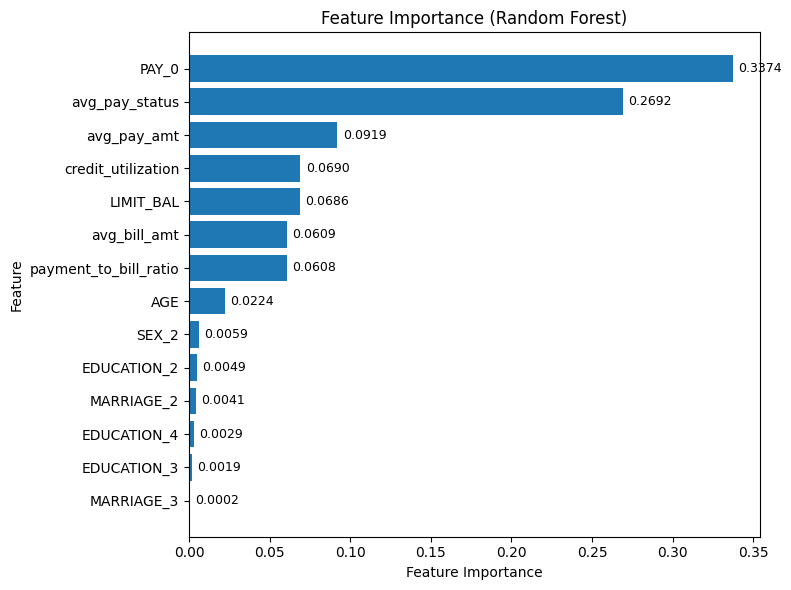

In [64]:
# =========================
# 4.11B Global Feature Importance
# =========================

if final_model_name == "Logistic Regression":

    feature_importance = pd.DataFrame({
        "feature": clean_feature_names,
        "coefficient": model_object.coef_[0]
    })

    feature_importance["abs_coefficient"] = (
        feature_importance["coefficient"].abs()
    )

    feature_importance = feature_importance.sort_values(
        "abs_coefficient",
        ascending=False
    ).reset_index(drop=True)

    display(feature_importance.head(15))

else:

    if final_model_name == "XGBoost":
        booster = model_object.get_booster()
        importance_dict = booster.get_score(importance_type="weight")

        importance_rows = []

        for feature_id, importance_value in importance_dict.items():
            feature_index = int(feature_id.replace("f", ""))

            importance_rows.append({
                "feature": clean_feature_names.iloc[feature_index],
                "importance": importance_value
            })

        feature_importance = pd.DataFrame(importance_rows)

    else:
        feature_importance = pd.DataFrame({
            "feature": clean_feature_names,
            "importance": model_object.feature_importances_
        })

    feature_importance = (
        feature_importance
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    feature_importance["rank"] = feature_importance.index + 1
    feature_importance["importance_pct"] = (
        feature_importance["importance"]
        / feature_importance["importance"].sum()
    )

    feature_importance = feature_importance[
        ["rank", "feature", "importance", "importance_pct"]
    ]

    display(feature_importance.head(15))

    top_importance = (
        feature_importance
        .head(15)
        .sort_values("importance")
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.barh(
        top_importance["feature"],
        top_importance["importance"],
        height=0.8
    )

    ax.set_title(f"Feature Importance ({final_model_name})")
    ax.set_xlabel(
        "F-score"
        if final_model_name == "XGBoost"
        else "Feature Importance"
    )
    ax.set_ylabel("Feature")

    max_importance = top_importance["importance"].max()

    for bar in bars:
        width = bar.get_width()

        ax.text(
            width + max_importance * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.0f}"
            if final_model_name == "XGBoost"
            else f"{width:.4f}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

SHAP values shape: (2000, 14)
Feature matrix shape: (2000, 14)


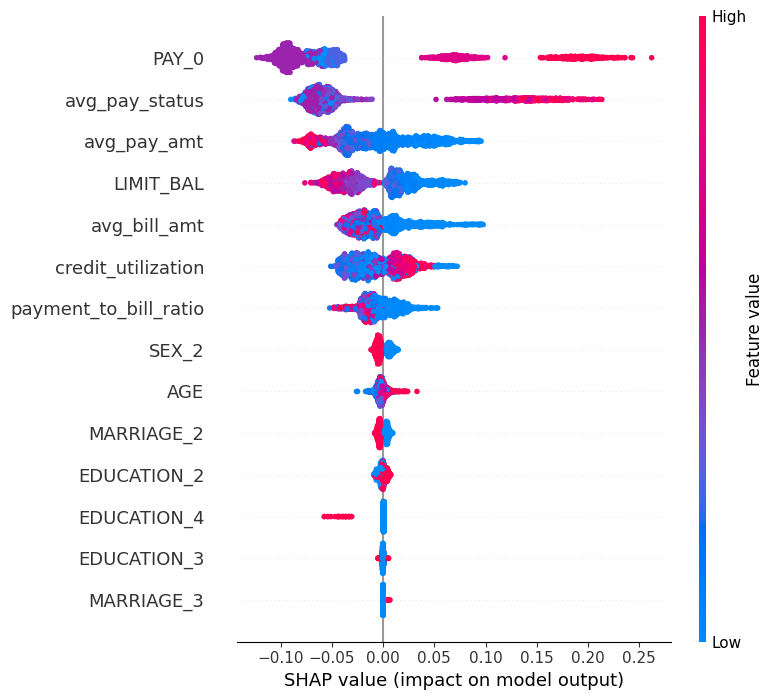

In [65]:
# =========================
# 4.11C SHAP Summary Plot
# =========================

try:
    import shap
    import numpy as np

    X_test_shap_sample = X_test_explain.sample(
        n=min(2000, len(X_test_explain)),
        random_state=42
    )

    if final_model_name in [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ]:
        explainer = shap.LinearExplainer(
            model_object,
            X_test_shap_sample
        )
        shap_values = explainer.shap_values(
            X_test_shap_sample
        )

    else:
        explainer = shap.TreeExplainer(model_object)
        shap_values = explainer.shap_values(
            X_test_shap_sample
        )

        # Old SHAP format: list[class]
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        # New SHAP format: samples × features × classes
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

    print("SHAP values shape:", np.asarray(shap_values).shape)
    print("Feature matrix shape:", X_test_shap_sample.shape)

    shap.summary_plot(
        shap_values,
        X_test_shap_sample,
        max_display=15,
        show=True
    )

except ImportError:
    print("SHAP is not installed. Run: pip install shap")

except Exception as error:
    print(f"SHAP analysis skipped: {error}")

In [66]:
# =========================
# 4.12 Add Final Model Predictions
# =========================

prediction_results["final_model"] = final_model_name
prediction_results["final_predicted_default"] = final_y_test_pred

prediction_results["final_predicted_PD_uncalibrated"] = final_y_test_pd_uncalibrated
prediction_results["final_predicted_PD"] = final_y_test_pd
prediction_results["pd_type"] = "Calibrated PD - Platt Scaling"

prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD,final_model,final_predicted_default,final_predicted_PD_uncalibrated,final_predicted_PD,pd_type
0,8942,0,0,0.1873,Random Forest,0,0.2109,0.0631,Calibrated PD - Platt Scaling
1,17619,1,0,0.2265,Random Forest,0,0.5681,0.3179,Calibrated PD - Platt Scaling
2,27896,0,0,0.1351,Random Forest,0,0.2698,0.0848,Calibrated PD - Platt Scaling
3,16104,0,0,0.3048,Random Forest,1,0.7104,0.5019,Calibrated PD - Platt Scaling
4,4423,0,0,0.2371,Random Forest,0,0.2520,0.0776,Calibrated PD - Platt Scaling


The final model predictions are added to the prediction results. The `final_predicted_PD` column will be used in the next sections for threshold analysis, Expected Loss calculation, and risk segmentation.

## 5. Threshold Analysis

The final selected model produces a calibrated Probability of Default for each customer. To convert these probabilities into binary risk classifications, an operating threshold must be selected.

A customer is classified as default when:

$$
\widehat{PD} \geq \text{threshold}
$$

and as non-default when:

$$
\widehat{PD} < \text{threshold}
$$

The default threshold of 0.50 may not be appropriate for credit risk management. A high threshold reduces false-positive alerts but may miss many customers who subsequently default. A lower threshold improves default detection but increases the number of non-default customers flagged for review.

This section evaluates multiple PD cutoffs and compares their effects on:

- precision;
- recall;
- F1-score;
- false-positive volume;
- false-negative risk.

The objective is to select an operating threshold that provides a practical balance between detecting default customers and controlling unnecessary risk alerts.

Threshold analysis is conducted using the calibrated PD values because these probabilities are more closely aligned with observed default frequencies. ROC-AUC and Gini remain unchanged across thresholds because they measure ranking performance rather than binary classification at a specific cutoff.

In [67]:
# =========================
# 5.1 Review Final Model Performance
# =========================

final_model_metrics


,Metric,Value
0,Final Model,Random Forest
1,PD Type,Calibrated PD - Platt Scaling
2,Accuracy,0.8123
3,Precision Default,0.6216
4,Recall Default,0.3877
5,F1 Default,0.4776
6,ROC-AUC,0.7776
7,Gini,0.5551


### Final Model Performance at the Current Threshold

The calibrated Random Forest achieves a ROC-AUC of **0.7776** and a Gini coefficient of **0.5551**, indicating reasonable discriminatory power.

At the current classification threshold, precision for the default class is **62.16%**, while recall is only **38.77%**. This means that default alerts are relatively reliable, but a large proportion of actual default customers remain undetected.

Therefore, the current threshold may be too conservative for a credit-risk monitoring application. The following analysis evaluates lower and higher PD cutoffs to identify a more suitable operating point.

In [68]:
# =========================
# 5.2 Confusion Matrix at 0.5 Threshold
# =========================

conf_matrix_05 = confusion_matrix(y_test, final_y_test_pred)

conf_matrix_05_df = pd.DataFrame(
    conf_matrix_05,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

conf_matrix_05_df

,Predicted Non-default,Predicted Default
Actual Non-default,6539,470
Actual Default,1219,772


In [69]:
tn, fp, fn, tp = conf_matrix_05.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 6539
False Positives: 470
False Negatives: 1219
True Positives: 772


In [70]:
# =========================
# 5.3 Threshold Comparison - Final Model
# =========================

thresholds = [0.5, 0.4, 0.3, 0.2]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (final_y_test_pd >= threshold).astype(int)
    
    accuracy_t = accuracy_score(y_test, y_pred_threshold)
    precision_t = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall_t = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1_t = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    conf_matrix_t = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = conf_matrix_t.ravel()
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_t,
        "precision": precision_t,
        "recall": recall_t,
        "f1_score": f1_t,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "predicted_default_count": y_pred_threshold.sum(),
        "predicted_default_rate": y_pred_threshold.mean()
    })

threshold_summary = pd.DataFrame(threshold_results)

threshold_summary

,threshold,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive,predicted_default_count,predicted_default_rate
0,0.5000,0.8123,0.6216,0.3877,0.4776,6539,470,1219,772,1242,0.1380
1,0.4000,0.8073,0.5803,0.4666,0.5173,6337,672,1062,929,1601,0.1779
2,0.3000,0.7926,0.5297,0.5560,0.5425,6026,983,884,1107,2090,0.2322
3,0.2000,0.7332,0.4331,0.6670,0.5252,5271,1738,663,1328,3066,0.3407


Lowering the classification threshold usually increases recall because more clients are classified as potential defaults. However, this often reduces precision because more non-default clients may also be flagged as default. This trade-off is important in credit risk decision-making.

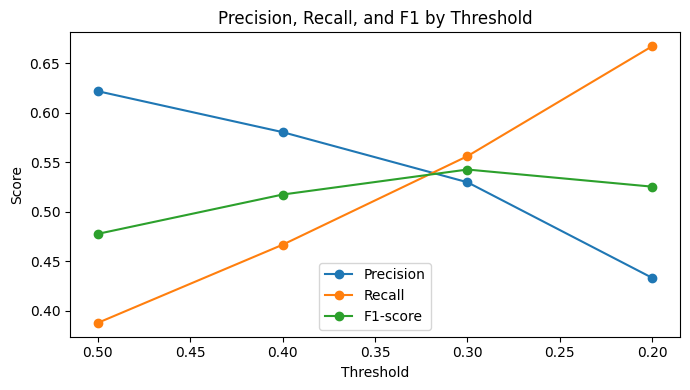

In [71]:
# =========================
# 5.4 Precision, Recall, and F1 by Threshold
# =========================

plt.figure(figsize=(7, 4))

plt.plot(threshold_summary["threshold"], threshold_summary["precision"], marker="o", label="Precision")
plt.plot(threshold_summary["threshold"], threshold_summary["recall"], marker="o", label="Recall")
plt.plot(threshold_summary["threshold"], threshold_summary["f1_score"], marker="o", label="F1-score")

plt.title("Precision, Recall, and F1 by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

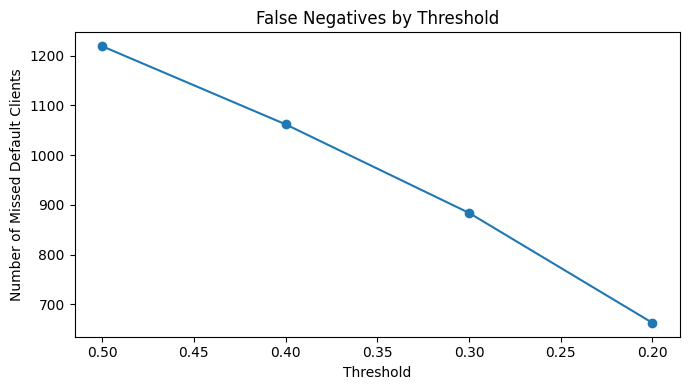

In [72]:
# =========================
# 5.5 False Negatives by Threshold
# =========================

plt.figure(figsize=(7, 4))

plt.plot(
    threshold_summary["threshold"],
    threshold_summary["false_negative"],
    marker="o"
)

plt.title("False Negatives by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Number of Missed Default Clients")

plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

### Threshold Selection Note

Among the tested cutoffs, a threshold of **0.30** produces the highest F1-score at **0.5425**. The F1-score is the harmonic mean of precision and recall:

$$
F1
=
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

Therefore, threshold 0.30 provides the best statistical balance between precision and recall when both metrics are treated as equally important.

However, this does not automatically make 0.30 the optimal business threshold. In credit risk management, false negatives may be more costly than false positives because missed default cases can lead to credit losses. The final operating threshold should therefore also consider the relative costs of missed defaults, unnecessary alerts, and operational review capacity.

Ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html?utm_source=chatgpt.com

In [73]:
# =========================
# 5.6 Choose Operating Threshold
# =========================

selected_threshold = 0.3

y_test_pred_selected = (final_y_test_pd >= selected_threshold).astype(int)

selected_conf_matrix = confusion_matrix(y_test, y_test_pred_selected)

selected_conf_matrix_df = pd.DataFrame(
    selected_conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

selected_conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6026,983
Actual Default,884,1107


In [74]:
selected_accuracy = accuracy_score(y_test, y_test_pred_selected)
selected_precision = precision_score(y_test, y_test_pred_selected, zero_division=0)
selected_recall = recall_score(y_test, y_test_pred_selected, zero_division=0)
selected_f1 = f1_score(y_test, y_test_pred_selected, zero_division=0)

selected_threshold_metrics = pd.DataFrame({
    "Metric": [
        "Final Model",
        "Selected Threshold",
        "Accuracy",
        "Precision Default",
        "Recall Default",
        "F1 Default",
        "ROC-AUC",
        "Gini"
    ],
    "Value": [
        final_model_name,
        selected_threshold,
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1,
        final_auc,
        final_gini
    ]
})

selected_threshold_metrics

,Metric,Value
0,Final Model,Random Forest
1,Selected Threshold,0.3000
2,Accuracy,0.7926
3,Precision Default,0.5297
4,Recall Default,0.5560
5,F1 Default,0.5425
6,ROC-AUC,0.7776
7,Gini,0.5551


In [75]:
# =========================
# 5.7 Add Selected Threshold Prediction
# =========================

prediction_results["predicted_default_selected_threshold"] = y_test_pred_selected
prediction_results["selected_threshold"] = selected_threshold

prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD,final_model,final_predicted_default,final_predicted_PD_uncalibrated,final_predicted_PD,pd_type,predicted_default_selected_threshold,selected_threshold
0,8942,0,0,0.1873,Random Forest,0,0.2109,0.0631,Calibrated PD - Platt Scaling,0,0.3000
1,17619,1,0,0.2265,Random Forest,0,0.5681,0.3179,Calibrated PD - Platt Scaling,1,0.3000
2,27896,0,0,0.1351,Random Forest,0,0.2698,0.0848,Calibrated PD - Platt Scaling,0,0.3000
3,16104,0,0,0.3048,Random Forest,1,0.7104,0.5019,Calibrated PD - Platt Scaling,1,0.3000
4,4423,0,0,0.2371,Random Forest,0,0.2520,0.0776,Calibrated PD - Platt Scaling,0,0.3000


## 6. Expected Loss and Portfolio Risk Analysis

This section converts calibrated next-month PD estimates into an illustrative borrower-level Expected Loss:

$$
EL = PD \times LGD \times EAD
$$

A constant LGD of 45% is used because recovery data are unavailable, while `BILL_AMT1` is used as a proxy for current drawn exposure. The results are used for sensitivity analysis, PD risk segmentation, portfolio aggregation, and Expected Loss concentration analysis.

The estimates represent a simplified short-horizon analytical framework rather than a regulatory IFRS 9 or Basel model.


In [76]:
# =========================
# 6.1 Create Scored Test Portfolio
# =========================

scored_portfolio = X_test.copy()

scored_portfolio.insert(
    0,
    "ID",
    df_model.loc[X_test.index, "ID"].values
)

scored_portfolio["actual_default"] = y_test.values
scored_portfolio["predicted_PD"] = final_y_test_pd
scored_portfolio["predicted_default_05"] = final_y_test_pred
scored_portfolio["predicted_default_selected_threshold"] = y_test_pred_selected
scored_portfolio["selected_threshold"] = selected_threshold

scored_portfolio.head()

,ID,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,actual_default,predicted_PD,predicted_default_05,predicted_default_selected_threshold,selected_threshold
8941,8942,230000,30,1,2,2,0,0.0000,"69,871.6667","2,804.8333",0.3038,0.0401,0,0.0631,0,0,0.3000
17618,17619,80000,32,2,1,1,-1,0.5000,"4,024.3333",807.3333,0.0503,0.2006,1,0.3179,0,1,0.3000
27895,27896,100000,29,2,1,2,0,0.0000,"83,106.0000","16,288.1667",0.8311,0.1960,0,0.0848,0,0,0.3000
16103,16104,10000,37,2,2,1,-1,2.0000,"2,664.6667",156.0000,0.2665,0.0585,0,0.5019,1,1,0.3000
4422,4423,110000,34,2,2,1,0,0.0000,"29,096.0000","2,816.6667",0.2645,0.0968,0,0.0776,0,0,0.3000


In [77]:
# =========================
# 6.2 Define LGD and EAD Assumptions
# =========================

BASE_LGD = 0.45

# Illustrative constant LGD assumption
scored_portfolio["LGD"] = BASE_LGD

# Current drawn exposure proxy
scored_portfolio["drawn_EAD"] = (
    df.loc[X_test.index, "BILL_AMT1"]
    .clip(lower=0)
    .to_numpy()
)

# Approved credit limit
scored_portfolio["credit_limit"] = (
    df.loc[X_test.index, "LIMIT_BAL"]
    .to_numpy()
)

# Remaining undrawn credit capacity
scored_portfolio["undrawn_amount"] = (
    scored_portfolio["credit_limit"]
    - scored_portfolio["drawn_EAD"]
).clip(lower=0)

# Base-case EAD uses the current drawn balance only
scored_portfolio["EAD"] = scored_portfolio["drawn_EAD"]

display(
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "LGD",
            "drawn_EAD",
            "undrawn_amount",
            "credit_limit",
            "EAD"
        ]
    ].head()
)

,ID,predicted_PD,LGD,drawn_EAD,undrawn_amount,credit_limit,EAD
8941,8942,0.0631,0.4500,101832,128168,230000,101832
17618,17619,0.3179,0.4500,4927,75073,80000,4927
27895,27896,0.0848,0.4500,167410,0,100000,167410
16103,16104,0.5019,0.4500,3305,6695,10000,3305
4422,4423,0.0776,0.4500,24147,85853,110000,24147


In [78]:
# =========================
# 6.3 Calculate Base-Case Expected Loss
# =========================

scored_portfolio["expected_loss"] = (
    scored_portfolio["predicted_PD"]
    * scored_portfolio["LGD"]
    * scored_portfolio["EAD"]
)

display(
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "LGD",
            "EAD",
            "expected_loss"
        ]
    ].head()
)

,ID,predicted_PD,LGD,EAD,expected_loss
8941,8942,0.0631,0.4500,101832,"2,890.5934"
17618,17619,0.3179,0.4500,4927,704.8500
27895,27896,0.0848,0.4500,167410,"6,385.2218"
16103,16104,0.5019,0.4500,3305,746.5068
4422,4423,0.0776,0.4500,24147,842.9828


### EAD Sensitivity Analysis

The base-case Expected Loss calculation uses the latest drawn balance, represented by `BILL_AMT1`, as the EAD proxy.

However, credit cards are revolving facilities. A customer experiencing financial difficulty may draw additional funds from the unused portion of the approved credit limit before default. Therefore, the exposure observed today may be lower than the exposure that would exist at the actual time of default.

To examine this uncertainty, scenario EAD is calculated as:

$$
EAD_{\text{scenario}}
=
\text{Drawn EAD}
+
CCF \times \text{Undrawn Amount}
$$

where:

- **Drawn EAD** is the current bill-statement balance;
- **Undrawn Amount** is the positive difference between the approved credit limit and the current drawn balance;
- **CCF** is an illustrative Credit Conversion Factor representing the proportion of the unused limit assumed to be drawn before default.

Three scenarios are evaluated:

- **CCF = 0%:** current drawn balance only;
- **CCF = 50%:** half of the remaining undrawn limit is assumed to be used;
- **CCF = 100%:** the full remaining undrawn limit is assumed to be used.

The 0%, 50%, and 100% CCF values are not estimated from the dataset and should not be interpreted as regulatory parameters. They are simplified sensitivity scenarios used to show how portfolio EAD and Expected Loss change under different assumptions about additional credit utilization before default.

In [79]:
# =========================
# 6.4 EAD Sensitivity Analysis
# =========================

ccf_scenarios = {
    "Drawn Balance Only": 0.00,
    "50% Undrawn Draw": 0.50,
    "Full Undrawn Draw": 1.00
}

ead_sensitivity_results = []

for scenario_name, ccf in ccf_scenarios.items():

    scenario_ead = (
        scored_portfolio["drawn_EAD"]
        + ccf * scored_portfolio["undrawn_amount"]
    )

    scenario_el = (
        scored_portfolio["predicted_PD"]
        * scored_portfolio["LGD"]
        * scenario_ead
    )

    ead_sensitivity_results.append({
        "scenario": scenario_name,
        "CCF": ccf,
        "total_EAD": scenario_ead.sum(),
        "average_EAD": scenario_ead.mean(),
        "total_expected_loss": scenario_el.sum(),
        "average_expected_loss": scenario_el.mean()
    })

ead_sensitivity = pd.DataFrame(ead_sensitivity_results)

base_ead_el = ead_sensitivity.loc[
    ead_sensitivity["CCF"].eq(0),
    "total_expected_loss"
].iloc[0]

ead_sensitivity["EL_uplift_vs_base"] = (
    ead_sensitivity["total_expected_loss"]
    / base_ead_el
    - 1
)

ead_sensitivity

,scenario,CCF,total_EAD,average_EAD,total_expected_loss,average_expected_loss,EL_uplift_vs_base
0,Drawn Balance Only,0.0000,"461,734,776.0000","51,303.8640","41,527,583.8697","4,614.1760",0.0000
1,50% Undrawn Draw,0.5000,"988,502,738.0000","109,833.6376","78,401,067.2166","8,711.2297",0.8879
2,Full Undrawn Draw,1.0000,"1,515,270,700.0000","168,363.4111","115,274,550.5634","12,808.2834",1.7759


In [80]:
# =========================
# 6.5 LGD Sensitivity Analysis
# =========================

lgd_scenarios = {
    "Low LGD": 0.30,
    "Base LGD": 0.45,
    "High LGD": 0.60
}

lgd_sensitivity_results = []

for scenario_name, lgd_value in lgd_scenarios.items():

    scenario_el = (
        scored_portfolio["predicted_PD"]
        * lgd_value
        * scored_portfolio["EAD"]
    )

    lgd_sensitivity_results.append({
        "scenario": scenario_name,
        "LGD": lgd_value,
        "total_expected_loss": scenario_el.sum(),
        "average_expected_loss": scenario_el.mean()
    })

lgd_sensitivity = pd.DataFrame(lgd_sensitivity_results)

base_lgd_el = lgd_sensitivity.loc[
    lgd_sensitivity["LGD"].eq(BASE_LGD),
    "total_expected_loss"
].iloc[0]

lgd_sensitivity["EL_uplift_vs_base"] = (
    lgd_sensitivity["total_expected_loss"]
    / base_lgd_el
    - 1
)

lgd_sensitivity

,scenario,LGD,total_expected_loss,average_expected_loss,EL_uplift_vs_base
0,Low LGD,0.3000,"27,685,055.9132","3,076.1173",-0.3333
1,Base LGD,0.4500,"41,527,583.8697","4,614.1760",0.0000
2,High LGD,0.6000,"55,370,111.8263","6,152.2346",0.3333


### Data-Driven PD Risk Bands

Internal credit-rating frameworks do not prescribe universal PD cutoffs for Low, Medium, and High Risk categories. Instead, rating boundaries should provide meaningful differentiation between borrowers and produce an ordered relationship between rating grade and observed default risk.

Accordingly, this project does not apply fixed PD thresholds. Two grade boundaries are estimated from the calibration sample using a shallow classification tree with three terminal groups.

The tree uses:

- calibrated Probability of Default as the segmentation variable;
- observed default status in the calibration sample as the target;
- a minimum segment size of 10% to avoid very small and unstable groups.

The resulting boundaries are then applied unchanged to the test portfolio to create:

- **Low Risk**;
- **Medium Risk**;
- **High Risk**.

The test set is not used to estimate the boundaries. It is used only to evaluate whether average PD and observed default rate increase across the ordered risk bands.

A suitable segmentation should satisfy:

$$
DR_{\text{Low}}
<
DR_{\text{Medium}}
<
DR_{\text{High}}
$$

where $DR$ denotes the observed default rate.

**Methodological basis:**

- Tasche, D. (2002), *Remarks on the Monotonicity of Default Probabilities*.
- Tasche, D. (2006), *Validation of Internal Rating Systems and PD Estimates*.
- *Credit Risk Modelling: ECL Model Development & Validation*, Section 2.4 — grade-boundary optimisation and grade-level backtesting.

In [81]:
# =========================
# 6.6 Create Data-Driven PD Risk Bands
# =========================

# Obtain calibrated PD estimates on the calibration set
calibration_pd = calibrated_model.predict_proba(
    X_calib_transformed
)[:, 1]

# Use calibration data to estimate two PD cutoffs.
# The tree creates three groups while requiring each group
# to contain at least 10% of the calibration sample.
pd_band_tree = DecisionTreeClassifier(
    max_leaf_nodes=3,
    min_samples_leaf=0.10,
    random_state=42
)

pd_band_tree.fit(
    calibration_pd.reshape(-1, 1),
    y_calib
)

# Extract the two learned PD thresholds
pd_cutoffs = np.sort(
    pd_band_tree.tree_.threshold[
        pd_band_tree.tree_.threshold >= 0
    ]
)

if len(pd_cutoffs) != 2:
    raise ValueError(
        "The PD band model did not produce exactly two cutoffs."
    )

low_pd_cutoff, high_pd_cutoff = pd_cutoffs

# Apply the learned cutoffs to the test portfolio
pd_band_bins = [
    -np.inf,
    low_pd_cutoff,
    high_pd_cutoff,
    np.inf
]

pd_band_labels = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

scored_portfolio["pd_risk_band"] = pd.cut(
    scored_portfolio["predicted_PD"],
    bins=pd_band_bins,
    labels=pd_band_labels,
    right=False,
    ordered=True
)

print(f"Low / Medium cutoff : {low_pd_cutoff:.4f}")
print(f"Medium / High cutoff: {high_pd_cutoff:.4f}")

display(
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "pd_risk_band",
            "expected_loss"
        ]
    ].head()
)

Low / Medium cutoff : 0.3213
Medium / High cutoff: 0.5997


,ID,predicted_PD,pd_risk_band,expected_loss
8941,8942,0.0631,Low Risk,"2,890.5934"
17618,17619,0.3179,Low Risk,704.8500
27895,27896,0.0848,Low Risk,"6,385.2218"
16103,16104,0.5019,Medium Risk,746.5068
4422,4423,0.0776,Low Risk,842.9828


### Expected Loss Concentration Analysis

Expected Loss is a continuous monetary risk measure:

$$
EL = PD \times LGD \times EAD
$$

No universal regulatory thresholds define borrower-level Expected Loss as Low, Medium, or High. Therefore, arbitrary percentile bands are not imposed in this analysis.

Instead, borrowers are ranked from the highest to the lowest Expected Loss. The analysis then calculates:

- each borrower's share of total portfolio Expected Loss;
- cumulative Expected Loss contribution;
- the proportion of borrowers responsible for the largest share of portfolio loss.

This approach provides a direct assessment of Expected Loss concentration without introducing unsupported monetary cutoffs.

A steep cumulative concentration curve indicates that a relatively small group of borrowers contributes a large proportion of total Expected Loss. These borrowers may be prioritised for additional review, monitoring, collection activity, or exposure management.

This analysis is related to Lorenz-style concentration analysis, in which observations are ranked by risk contribution and evaluated through their cumulative share.

**Methodological basis:**

- *Credit Risk Theory*, discussion of Lorenz curves and cumulative risk-ranking analysis.
- Basel-style portfolio risk management principles requiring risk to be assessed at both individual-exposure and portfolio levels.

In [82]:
# =========================
# 6.7 Expected Loss Concentration Analysis
# =========================

el_concentration = (
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "EAD",
            "expected_loss",
            "pd_risk_band",
            "actual_default"
        ]
    ]
    .sort_values(
        "expected_loss",
        ascending=False
    )
    .reset_index(drop=True)
)

el_concentration["borrower_rank"] = (
    np.arange(1, len(el_concentration) + 1)
)

total_portfolio_el = (
    el_concentration["expected_loss"].sum()
)

el_concentration["EL_share"] = (
    el_concentration["expected_loss"]
    / total_portfolio_el
)

el_concentration["cumulative_EL_share"] = (
    el_concentration["EL_share"].cumsum()
)

el_concentration = el_concentration[
    [
        "borrower_rank",
        "ID",
        "predicted_PD",
        "EAD",
        "expected_loss",
        "EL_share",
        "cumulative_EL_share",
        "pd_risk_band",
        "actual_default"
    ]
]

display(el_concentration.head(15))

,borrower_rank,ID,predicted_PD,EAD,expected_loss,EL_share,cumulative_EL_share,pd_risk_band,actual_default
0,1,10769,0.5744,564757,"145,986.0196",0.0035,0.0035,Medium Risk,1
1,2,19486,0.6219,506515,"141,761.2593",0.0034,0.0069,High Risk,1
2,3,27499,0.5032,613860,"138,989.2121",0.0033,0.0103,Medium Risk,1
3,4,15594,0.5961,458652,"123,038.8282",0.0030,0.0132,Medium Risk,1
4,5,4704,0.6158,435924,"120,806.8311",0.0029,0.0161,High Risk,1
5,6,19668,0.6042,420522,"114,337.7473",0.0028,0.0189,High Risk,0
6,7,27035,0.5879,426429,"112,822.8893",0.0027,0.0216,Medium Risk,1
7,8,15317,0.5644,412289,"104,721.0362",0.0025,0.0241,Medium Risk,1
8,9,14589,0.7004,327918,"103,350.7805",0.0025,0.0266,High Risk,0
9,10,1497,0.6336,360023,"102,654.3214",0.0025,0.0291,High Risk,1


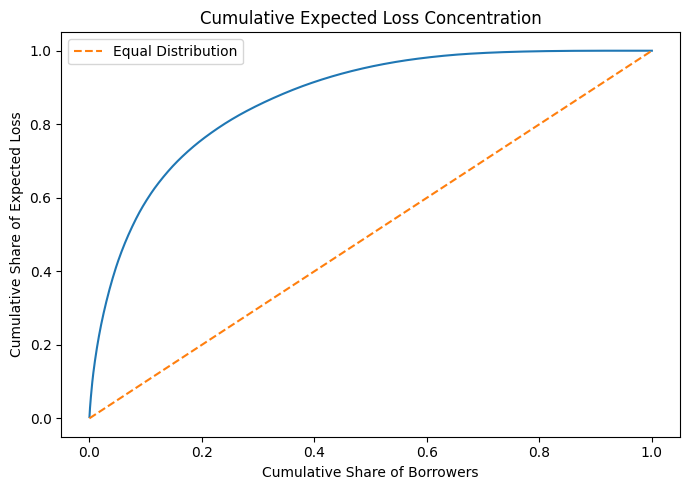

In [83]:
# Percentage of borrowers after ranking by Expected Loss
borrower_share = (
    np.arange(1, len(el_concentration) + 1)
    / len(el_concentration)
)

plt.figure(figsize=(7, 5))

plt.plot(
    borrower_share,
    el_concentration["cumulative_EL_share"]
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Equal Distribution"
)

plt.title("Cumulative Expected Loss Concentration")
plt.xlabel("Cumulative Share of Borrowers")
plt.ylabel("Cumulative Share of Expected Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
# =========================
# 6.8 Portfolio-Level Expected Loss Summary
# =========================

total_ead = scored_portfolio["EAD"].sum()
total_expected_loss = scored_portfolio["expected_loss"].sum()

portfolio_summary = pd.DataFrame({
    "loss_horizon": ["Next Month"],
    "EAD_method": ["BILL_AMT1 Drawn-Balance Proxy"],
    "LGD_method": ["Constant 45% Base-Case Assumption"],
    "total_customers": [len(scored_portfolio)],
    "total_EAD": [total_ead],
    "average_PD": [scored_portfolio["predicted_PD"].mean()],
    "average_LGD": [scored_portfolio["LGD"].mean()],
    "total_expected_loss": [total_expected_loss],
    "average_expected_loss": [
        scored_portfolio["expected_loss"].mean()
    ],
    "expected_loss_rate": [
        total_expected_loss / total_ead
    ],
    "actual_default_rate": [
        scored_portfolio["actual_default"].mean()
    ]
})

portfolio_summary

,loss_horizon,EAD_method,LGD_method,total_customers,total_EAD,average_PD,average_LGD,total_expected_loss,average_expected_loss,expected_loss_rate,actual_default_rate
0,Next Month,BILL_AMT1 Drawn-Balance Proxy,Constant 45% Base-Case Assumption,9000,461734776,0.2208,0.4500,"41,527,583.8697","4,614.1760",0.0899,0.2212


In [85]:
# =========================
# 6.9 Summary by PD Risk Band
# =========================

pd_risk_summary = (
    scored_portfolio
    .groupby("pd_risk_band", observed=False)
    .agg(
        customer_count=("ID", "count"),
        total_EAD=("EAD", "sum"),
        average_PD=("predicted_PD", "mean"),
        actual_default_rate=("actual_default", "mean"),
        total_expected_loss=("expected_loss", "sum"),
        average_expected_loss=("expected_loss", "mean")
    )
    .reset_index()
)

pd_risk_summary["portfolio_EL_share"] = (
    pd_risk_summary["total_expected_loss"]
    / pd_risk_summary["total_expected_loss"].sum()
)

pd_risk_summary

,pd_risk_band,customer_count,total_EAD,average_PD,actual_default_rate,total_expected_loss,average_expected_loss,portfolio_EL_share
0,Low Risk,7049,371299367,0.1276,0.1309,"17,131,677.7072","2,430.3699",0.4125
1,Medium Risk,1065,37016205,0.4524,0.4329,"8,099,289.3246","7,604.9665",0.1950
2,High Risk,886,53419204,0.6834,0.6851,"16,296,616.8380","18,393.4727",0.3924


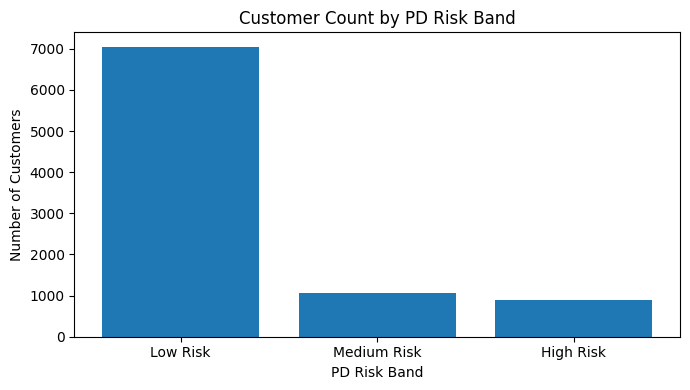

In [86]:
# =========================
# 6.10 Customer Count by PD Risk Band
# =========================

plt.figure(figsize=(7, 4))

plt.bar(
    pd_risk_summary["pd_risk_band"],
    pd_risk_summary["customer_count"]
)

plt.title("Customer Count by PD Risk Band")
plt.xlabel("PD Risk Band")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

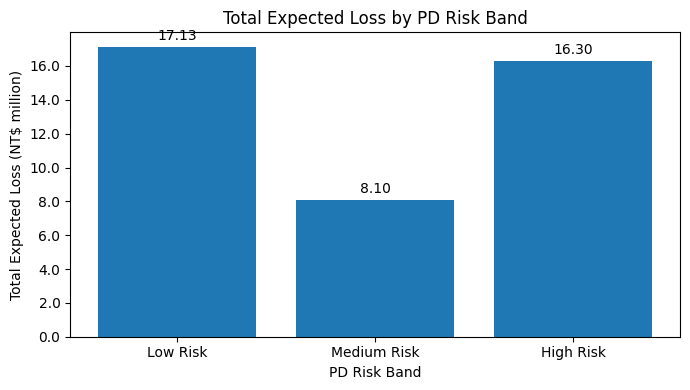

In [87]:
# =========================
# 6.11 Expected Loss by PD Risk Band
# =========================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    pd_risk_summary["pd_risk_band"],
    pd_risk_summary["total_expected_loss"]
)

ax.set_title("Total Expected Loss by PD Risk Band")
ax.set_xlabel("PD Risk Band")
ax.set_ylabel("Total Expected Loss (NT$ million)")

# Convert axis values from NT$ to million NT$
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value / 1_000_000:,.1f}")
)

# Add value labels above the bars
for bar in bars:
    value = bar.get_height()

    ax.annotate(
        f"{value / 1_000_000:,.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [88]:
# =========================
# 6.12 Top Borrowers by Expected Loss
# =========================

top_el_borrowers = (
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "drawn_EAD",
            "undrawn_amount",
            "credit_limit",
            "LGD",
            "expected_loss",
            "pd_risk_band",
            "actual_default"
        ]
    ]
    .sort_values("expected_loss", ascending=False)
    .head(10)
)

top_el_borrowers

,ID,predicted_PD,drawn_EAD,undrawn_amount,credit_limit,LGD,expected_loss,pd_risk_band,actual_default
10768,10769,0.5744,564757,0,500000,0.4500,"145,986.0196",Medium Risk,1
19485,19486,0.6219,506515,0,280000,0.4500,"141,761.2593",High Risk,1
27498,27499,0.5032,613860,0,500000,0.4500,"138,989.2121",Medium Risk,1
15593,15594,0.5961,458652,141348,600000,0.4500,"123,038.8282",Medium Risk,1
4703,4704,0.6158,435924,84076,520000,0.4500,"120,806.8311",High Risk,1
19667,19668,0.6042,420522,0,210000,0.4500,"114,337.7473",High Risk,0
27034,27035,0.5879,426429,0,420000,0.4500,"112,822.8893",Medium Risk,1
15316,15317,0.5644,412289,7711,420000,0.4500,"104,721.0362",Medium Risk,1
14588,14589,0.7004,327918,0,280000,0.4500,"103,350.7805",High Risk,0
1496,1497,0.6336,360023,0,360000,0.4500,"102,654.3214",High Risk,1


In [89]:
# =========================
# 6.14 Predicted PD and EL by Observed Default Status
# =========================

actual_default_el_summary = (
    scored_portfolio
    .groupby("actual_default")
    .agg(
        customer_count=("ID", "count"),
        average_PD=("predicted_PD", "mean"),
        average_EAD=("EAD", "mean"),
        total_expected_loss=("expected_loss", "sum"),
        average_expected_loss=("expected_loss", "mean")
    )
    .reset_index()
)

actual_default_el_summary

,actual_default,customer_count,average_PD,average_EAD,total_expected_loss,average_expected_loss
0,0,7009,0.1730,"51,596.6017","23,903,521.3159","3,410.4040"
1,1,1991,0.3889,"50,273.3275","17,624,062.5539","8,851.8647"


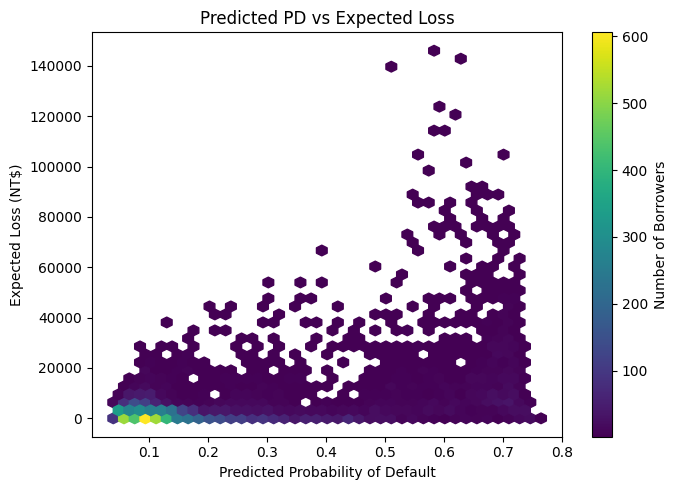

In [95]:
plt.figure(figsize=(7, 5))

hex_plot = plt.hexbin(
    scored_portfolio["predicted_PD"],
    scored_portfolio["expected_loss"],
    gridsize=40,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(
    hex_plot,
    label="Number of Borrowers"
)

plt.title("Predicted PD vs Expected Loss")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Expected Loss (NT$)")

plt.tight_layout()

## Conclusion, Limitations, and Future Work

### Conclusion

This project developed an end-to-end workflow for predicting next-month credit card default.

The analysis included data preparation, feature engineering, model comparison, probability calibration, threshold evaluation, and borrower-level Expected Loss estimation.

Random Forest was selected as the final model, achieving a test ROC-AUC of approximately **0.778**. Platt Scaling improved probability calibration while preserving discriminatory performance.

Repayment behavior, particularly recent payment status and average repayment history, was among the most important predictors of default.

Calibrated PD estimates were then translated into an illustrative Expected Loss measure:

$$
EL = PD \times LGD \times EAD
$$

This allowed the analysis to evaluate both borrower-level default risk and portfolio-level monetary loss concentration.

### Limitations

This project is an educational implementation rather than a production or regulatory credit-risk model.

Key limitations include:

- the target represents next-month default rather than 12-month or lifetime PD;
- the dataset is historical and comes from a single credit card portfolio;
- LGD is assumed rather than estimated from recovery data;
- `BILL_AMT1` is used as a proxy for drawn EAD;
- CCF scenarios are illustrative and not estimated from observed drawdown behavior;
- Expected Loss cannot be backtested because realized loss and recovery data are unavailable;
- the model has not been validated on an external or later-period dataset.

Therefore, the resulting Expected Loss should be interpreted as a simplified short-horizon portfolio-risk estimate.

### Future Work

Future development could include:

- temporal and external model validation;
- 12-month and lifetime PD estimation;
- portfolio-specific LGD and CCF models;
- macroeconomic scenario analysis;
- population and calibration drift monitoring;
- a traditional Logistic Regression scorecard as an interpretable benchmark;
- deployment through an automated scoring pipeline and risk dashboard.

Overall, the project demonstrates how calibrated default probabilities can be combined with exposure assumptions to support borrower prioritization and portfolio risk analysis.